# LINet3 Training + Diagnostics on SUN RGB-D

**Complete training pipeline with gradient health monitoring, stream contribution analysis, and internal CNN visualization**

---

## Checklist Before Running:

- [ ] **Enable A100 GPU:** Runtime -> Change runtime type -> Hardware accelerator: GPU -> GPU type: A100
- [ ] **Mount Google Drive:** Your code and dataset will be stored on Drive
- [ ] **Upload dataset to Drive:** `MyDrive/datasets/sunrgbd_15_train_test.tar.gz` (train + test splits)

---

## What This Notebook Does:

**Training with Full Diagnostics:**
1. Train LINet3 (2-stream: RGB + Depth) on SUN RGB-D 15-category
2. Gradient health monitoring (vanishing/exploding/oscillating detection)
3. Per-stream training loss decomposition
4. Integration weight evolution tracking

**Post-Training Visualization Suite:**
5. Feature map visualization (full model, per-stream, ablation)
6. Stream contribution decomposition (what each stream contributes to each neuron)
7. Stream-decomposed Grad-CAM (where each stream focuses attention)
8. Integration weight analysis (learned fusion priorities per layer)
9. Stream redundancy analysis (are streams learning the same thing?)
10. Per-class stream dominance (which scenes rely on RGB vs Depth?)
11. Misclassification analysis with Grad-CAM comparison
12. Train vs test activation divergence + BN stats reset experiment

---

## About LINet3:

**LINet3** (Linear Integration Network v3) is an N-stream ResNet where fusion happens **inside each convolution neuron**:
- Per-stream independent convolution kernels (full spatial filters)
- Learned 1x1 integration weights that combine stream outputs at every layer
- Integrated pathway carries the fused representation forward

This allows the network to learn **layer-specific, spatially-aware integration strategies**.

## 1. Environment Setup & GPU Verification

In [1]:
# Check GPU availability and specs
import torch
import subprocess

print("=" * 60)
print("GPU VERIFICATION")
print("=" * 60)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

    gpu_name = torch.cuda.get_device_name(0)
    if 'A100' in gpu_name:
        print("\nA100 GPU detected - optimal for training")
    elif 'V100' in gpu_name:
        print("\nV100 GPU detected - good for training (slower than A100)")
    elif 'T4' in gpu_name:
        print("\nT4 GPU detected - will be slower, consider upgrading to A100")
    else:
        print(f"\nGPU: {gpu_name}")
else:
    print("\nNO GPU DETECTED!")
    print("Enable GPU: Runtime -> Change runtime type -> Hardware accelerator: GPU")
    raise RuntimeError("GPU is required for training")

print("\n" + "=" * 60)

GPU VERIFICATION
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU Device: Tesla T4
GPU Memory: 14.56 GB

T4 GPU detected - will be slower, consider upgrading to A100



In [2]:
# Detailed GPU info
!nvidia-smi

Tue Mar 24 04:11:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             16W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Google Drive

In [3]:
from google.colab import drive
import os
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

print("\nGoogle Drive mounted successfully!")
print(f"\nDrive contents:")
!ls -la /content/drive/MyDrive/ | head -20

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Google Drive mounted successfully!

Drive contents:
total 3117887
-rw------- 1 root root        176 Sep 21  2019 06-lab2.gdoc
-rw------- 1 root root      21621 Sep 30  2024 113-1363667-3121001@USSR24093000064918@pre-paid.png
-rw------- 1 root root        176 Aug 13  2020 2020 summer final (1).gdoc
-rw------- 1 root root        176 Aug 13  2020 2020 summer final (2).gdoc
-rw------- 1 root root        176 Aug 13  2020 2020 summer final (3).gdoc
-rw------- 1 root root        176 Aug 13  2020 2020 summer final.gdoc
-rw------- 1 root root        176 Jul 11  2025 2025_Gabriel_Clinger_Contractor Agreement_BASE copy.gdoc
-rw------- 1 root root      32204 Apr 18  2022 2900 On First- Welcome Home Next Steps.docx
-rw------- 1 root root       8822 Jun 24  2017 A6.docx
-rw------- 1 root root      22204 Jan 21  2023 activity (1).xlsx
-rw------- 1 root root      22161 Jan 

## 3. Clone Repository to Local Disk (Fast I/O)

**Important:** We clone to `/content/` (local SSD) instead of Drive for 10-20x faster I/O

**Default:** Clone from GitHub (recommended - always gets latest code)

In [4]:
import os
from pathlib import Path

# Configuration
PROJECT_NAME = "Multi-Stream-Neural-Networks"
GITHUB_REPO = "https://github.com/clingergab/Multi-Stream-Neural-Networks.git"
LOCAL_REPO_PATH = f"/content/{PROJECT_NAME}"

print("=" * 60)
print("REPOSITORY SETUP")
print("=" * 60)

os.chdir('/content')

if Path(LOCAL_REPO_PATH).exists() and Path(f"{LOCAL_REPO_PATH}/.git").exists():
    print(f"Repo already exists: {LOCAL_REPO_PATH}")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
else:
    if Path(LOCAL_REPO_PATH).exists():
        !rm -rf {LOCAL_REPO_PATH}
    print(f"Cloning from {GITHUB_REPO}...")
    !git clone {GITHUB_REPO} {LOCAL_REPO_PATH}
    if not Path(LOCAL_REPO_PATH).exists():
        raise RuntimeError(f"Failed to clone repository")
    os.chdir(LOCAL_REPO_PATH)

print(f"\nWorking directory: {os.getcwd()}")
!ls -la {LOCAL_REPO_PATH}
print("\n" + "=" * 60)

REPOSITORY SETUP
Repo already exists: /content/Multi-Stream-Neural-Networks
Already up to date.

Working directory: /content/Multi-Stream-Neural-Networks
total 84
drwxr-xr-x 12 root root  4096 Mar 24 03:03 .
drwxr-xr-x  1 root root  4096 Mar 24 03:03 ..
drwxr-xr-x  5 root root  4096 Mar 24 03:03 configs
drwxr-xr-x  2 root root  4096 Mar 24 03:03 data
drwxr-xr-x  4 root root  4096 Mar 24 03:03 docs
drwxr-xr-x  3 root root  4096 Mar 24 03:03 experiments
drwxr-xr-x  9 root root  4096 Mar 24 04:11 .git
-rw-r--r--  1 root root   732 Mar 24 03:03 .gitattributes
drwxr-xr-x  3 root root  4096 Mar 24 03:03 .github
-rw-r--r--  1 root root   847 Mar 24 03:03 .gitignore
-rw-r--r--  1 root root  1084 Mar 24 03:03 LICENSE
drwxr-xr-x  2 root root  4096 Mar 24 03:03 notebooks
-rw-r--r--  1 root root   198 Mar 24 03:03 pytest.ini
-rw-r--r--  1 root root  3884 Mar 24 03:03 README.md
-rw-r--r--  1 root root   126 Mar 24 03:03 requirements.txt
drwxr-xr-x  2 root root  4096 Mar 24 03:03 scripts
-rw-r--r-- 

## 4. Install Dependencies

In [5]:
# Install required packages
print("Installing dependencies...")

!pip install -q h5py tqdm matplotlib seaborn ray[tune] kornia

# Verify installations
import h5py
import tqdm
import matplotlib
import seaborn
import kornia

print("All dependencies installed!")
print(f"   h5py: {h5py.__version__}")
print(f"   matplotlib: {matplotlib.__version__}")
print(f"   kornia: {kornia.__version__}")

Installing dependencies...
All dependencies installed!
   h5py: 3.16.0
   matplotlib: 3.10.0
   kornia: 0.8.2


## 5. Copy SUN RGB-D Dataset to Local Disk

**Performance Note:** Local disk I/O is ~10-20x faster than Drive!

**Dataset:** SUN RGB-D 15-category preprocessed (train + test splits, RGB + Depth)

In [6]:
from pathlib import Path
import os

# Paths
DRIVE_DATASET_TAR = "/content/drive/MyDrive/datasets/sunrgbd_19_traintest.tar.gz"
LOCAL_DATASET_PATH = "/dev/shm/sunrgbd_19_traintest"  # Extracted location

print("=" * 60)
print("SUN RGB-D 15-CATEGORY DATASET SETUP (TRAIN + TEST)")
print("=" * 60)

# Check if already on local disk
if Path(LOCAL_DATASET_PATH).exists():
    print(f"Dataset already on local disk: {LOCAL_DATASET_PATH}")

    # Verify structure
    for split in ['train', 'test']:
        split_dir = Path(f"{LOCAL_DATASET_PATH}/{split}/rgb")
        if split_dir.exists():
            count = len(list(split_dir.glob("*.png")))
            print(f"   {split.capitalize()} samples: {count}")

# Copy and extract from Drive
elif Path(DRIVE_DATASET_TAR).exists():
    print(f"Found compressed dataset on Drive: {DRIVE_DATASET_TAR}")
    print(f"Copying compressed file to local disk...")

    # Copy compressed file with progress
    !rsync -ah --info=progress2 {DRIVE_DATASET_TAR} /dev/shm/sunrgbd_19_traintest.tar.gz

    # Extract to local disk
    print(f"\nExtracting dataset to local disk...")
    !tar -xzf /dev/shm/sunrgbd_19_traintest.tar.gz -C /dev/shm/ 2>&1 | grep -v "Ignoring unknown extended header"

    # Remove tar file to save space
    !rm /dev/shm/sunrgbd_19_traintest.tar.gz

    print(f"\nDataset extracted to local disk")

    # Verify extraction
    for split in ['train', 'test']:
        split_dir = Path(f"{LOCAL_DATASET_PATH}/{split}/rgb")
        if split_dir.exists():
            count = len(list(split_dir.glob("*.png")))
            print(f"   {split.capitalize()} samples: {count}")

else:
    print(f"Dataset not found on Drive!")
    print(f"   Expected location: {DRIVE_DATASET_TAR}")
    raise FileNotFoundError(f"Compressed dataset not found at {DRIVE_DATASET_TAR}")

print("\n" + "=" * 60)
print(f"Dataset ready at: {LOCAL_DATASET_PATH}")
print("=" * 60)

SUN RGB-D 15-CATEGORY DATASET SETUP (TRAIN + TEST)
Dataset already on local disk: /dev/shm/sunrgbd_19_traintest

Dataset ready at: /dev/shm/sunrgbd_19_traintest


## 6. Setup Python Path & Import LINet3

In [7]:
import sys
import os

# Remove cached modules
modules_to_reload = [k for k in sys.modules.keys() if k.startswith('src.')]
for module in modules_to_reload:
    del sys.modules[module]

# Add project to Python path
project_root = '/content/Multi-Stream-Neural-Networks'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Verify project structure
print("Project structure:")
!ls -la {project_root}/src/models/

# Import LiNet and dataloaders
print("\nImporting LiNet, dataloaders, and visualization tools...")
from src.models.linear_integration.li_net3 import li_resnet18
from src.models.linear_integration.li_net3.conv import LIBatchNorm2d
from src.data_utils.sunrgbd_dataset import get_sunrgbd_dataloaders
from src.training.augmentation_config import AugmentationConfig

# Import visualization suite
from src.utils.visualization import (
    FeatureMapVisualizer,
    StreamContributionVisualizer,
    StreamGradCAM,
    IntegrationWeightVisualizer,
    find_misclassified,
    compare_samples,
    StreamRedundancyAnalyzer,
    PerClassDominanceAnalyzer,
    ActivationDivergenceAnalyzer,
    IntegrationWeightEvolutionVisualizer,
    reset_bn_stats,
)

print("All imports successful!")

Project structure:
total 52
drwxr-xr-x 12 root root 4096 Mar 24 03:04 .
drwxr-xr-x  8 root root 4096 Mar 24 03:04 ..
drwxr-xr-x  3 root root 4096 Mar 24 03:04 abstracts
drwxr-xr-x  3 root root 4096 Mar 24 03:04 common
drwxr-xr-x  3 root root 4096 Mar 24 03:04 core
drwxr-xr-x  2 root root 4096 Mar 24 03:03 direct_mixing_activation
drwxr-xr-x  2 root root 4096 Mar 24 03:03 direct_mixing_bn
drwxr-xr-x  2 root root 4096 Mar 24 03:03 direct_mixing_conv
-rw-r--r--  1 root root 1076 Mar 24 03:03 __init__.py
drwxr-xr-x  5 root root 4096 Mar 24 03:04 linear_integration
drwxr-xr-x  3 root root 4096 Mar 24 03:04 multi_channel
drwxr-xr-x  2 root root 4096 Mar 24 03:04 __pycache__
drwxr-xr-x  2 root root 4096 Mar 24 03:03 utils

Importing LiNet, dataloaders, and visualization tools...
All imports successful!


In [8]:
# Set random seed for reproducibility
from src.utils.seed import set_seed

SEED = 42
DETERMINISTIC = False  # False = faster, True = fully reproducible

set_seed(SEED, deterministic=DETERMINISTIC)

print(f"Seed: {SEED}, Deterministic: {DETERMINISTIC}")

Seed: 42, Deterministic: False


## 7. Configuration

All hyperparameters and settings in one place. Modify these before running.

In [9]:
from src.training.augmentation_config import AugmentationConfig

# ======================== DATASET ========================
DATASET_CONFIG = {
    'data_root': LOCAL_DATASET_PATH,
    'batch_size': 64,
    'num_workers': 8,
    'num_classes': 19,
    'seed': SEED
}

AUGMENTATION_CONFIG = AugmentationConfig(
    rgb_aug_prob=1.076,
    rgb_aug_mag=1.006,
    depth_aug_prob=1.014,
    depth_aug_mag=1.149,
)

# ======================== MODEL ========================
MODEL_CONFIG = {
    'architecture': 'resnet18',
    'num_classes': 19,
    'stream_input_channels': [3, 1],  # RGB=3, Depth=1
    'width_multiplier': 0.75,
    'dropout_p': 0.515,
    'device': 'cuda',
    'use_amp': True
}

STREAM_LABELS = {0: 'RGB', 1: 'Depth'}

# ======================== OPTIMIZER ========================
STREAM_SPECIFIC_CONFIG = {
    'stream_lrs': [7.22e-05, 1.59e-04],        # [RGB, Depth]
    'shared_lr': 1.63e-04,
    'stream_weight_decays': [6.33e-05, 4.25e-05],  # [RGB, Depth]
    'integration_weight_decay': 1.30e-04,
}

SCHEDULER_CONFIG = {
    'scheduler_type': 'cosine',
    't_max': 115,
    's1_eta': 9.64e-07,
    's2_eta': 2.45e-06,
    'eta_min': 6.57e-07,
    'warmup_epochs': 5,
    'warmup_start_factor': 0.2
}

# ======================== TRAINING ========================
TRAIN_CONFIG = {
    'epochs': 120,
    'grad_clip_norm': 0.760,
    'early_stopping': False,  # No val set
    'restore_best_weights': True,
    'stream_monitoring': True,
    'modality_dropout': True,
    'modality_dropout_start':5,
    'modality_dropout_ramp':20,
    'modality_dropout_rate': 0.124,
    'label_smoothing': 0.119,
    # Gradient health monitoring
    'gradient_monitoring': True,
    'gradient_log_freq': 0,  # Last batch per epoch
    # Integration weight tracking
    'track_integration_weights': True,
    'integration_snapshot_freq': 10,
}

# Print summary
print('All configs defined.')
print(f'  Dataset: {DATASET_CONFIG["data_root"]}')
print(f'  Model: LINet3-{MODEL_CONFIG["architecture"]} ({len(MODEL_CONFIG["stream_input_channels"])}-stream)')
print(f'  Streams: {STREAM_LABELS}')
print(f'  Epochs: {TRAIN_CONFIG["epochs"]}, Grad clip: {TRAIN_CONFIG["grad_clip_norm"]}')
print(f'  Gradient monitoring: {TRAIN_CONFIG["gradient_monitoring"]}')
print(f'  Integration weight tracking: {TRAIN_CONFIG["track_integration_weights"]}')


All configs defined.
  Dataset: /dev/shm/sunrgbd_19_traintest
  Model: LINet3-resnet18 (2-stream)
  Streams: {0: 'RGB', 1: 'Depth'}
  Epochs: 120, Grad clip: 0.76
  Gradient monitoring: True
  Integration weight tracking: True


## 8. Load Dataset

In [10]:
# Verify dataset structure
from pathlib import Path

print("=" * 60)
print("DATASET STRUCTURE VERIFICATION")
print("=" * 60)

dataset_root = Path(LOCAL_DATASET_PATH)

print("\nDirectory structure:")
print(f"  {dataset_root}/")
for split in ['train', 'test']:
    split_dir = dataset_root / split
    if split_dir.exists():
        print(f"    {split}/")
        for modality in ['rgb', 'depth']:
            mod_dir = split_dir / modality
            if mod_dir.exists():
                print(f"      {modality}/ - {len(list(mod_dir.glob('*.png')))} images")
        print(f"      labels.txt")

# Read class names
class_names_file = dataset_root / 'class_names.txt'
if class_names_file.exists():
    with open(class_names_file, 'r') as f:
        class_names = [line.strip() for line in f]
    print(f"\nClasses ({len(class_names)}):")
    for i, name in enumerate(class_names):
        print(f"  {i}: {name}")

print("\n" + "=" * 60)

DATASET STRUCTURE VERIFICATION

Directory structure:
  /dev/shm/sunrgbd_19_traintest/
    train/
      labels.txt
    test/
      labels.txt

Classes (19):
  0: 0: bathroom
  1: 1: bedroom
  2: 2: classroom
  3: 3: computer_room
  4: 4: conference_room
  5: 5: corridor
  6: 6: dining_area
  7: 7: dining_room
  8: 8: discussion_area
  9: 9: furniture_store
  10: 10: home_office
  11: 11: kitchen
  12: 12: lab
  13: 13: lecture_theatre
  14: 14: library
  15: 15: living_room
  16: 16: office
  17: 17: rest_space
  18: 18: study_space



In [11]:
print("=" * 60)
print("LOADING SUN RGB-D 19-CATEGORY DATASET (TRAIN + TEST)")
print("=" * 60)

print(f"\nLoading dataset from: {DATASET_CONFIG['data_root']}")

# Create dataloaders (val_loader will be None since no val/ directory)
train_loader, val_loader, test_loader = get_sunrgbd_dataloaders(
    data_root=DATASET_CONFIG['data_root'],
    batch_size=DATASET_CONFIG['batch_size'],
    num_workers=DATASET_CONFIG['num_workers'],
    seed=DATASET_CONFIG['seed'],
    **AUGMENTATION_CONFIG.to_dict(),
    stratified=True,
    normalize=True
)

print(f"\nDataset loaded!")
print(f"  Train: {len(train_loader.dataset)} samples ({len(train_loader)} batches)")
print(f"  Test: {len(test_loader.dataset)} samples ({len(test_loader)} batches)")
print(f"  Val: {'None (no val split)' if val_loader is None else f'{len(val_loader.dataset)} samples'}")

# Test loading a batch
rgb_batch, depth_batch, label_batch = next(iter(train_loader))
print(f"\nBatch shapes: RGB={rgb_batch.shape}, Depth={depth_batch.shape}, Labels={label_batch.shape}")

print("\n" + "=" * 60)

LOADING SUN RGB-D 19-CATEGORY DATASET (TRAIN + TEST)

Loading dataset from: /dev/shm/sunrgbd_19_traintest
Loaded SUN RGB-D train: 4845 samples, 19 classes (tensors, mmap)

Augmentation scaling applied:
  RGB:   prob=1.08, mag=1.01
  Depth: prob=1.01, mag=1.15
  Computed values:
    [Sync]  Flip prob: 0.50 -> 0.522
    [RGB]   ColorJitter prob: 0.43 -> 0.463
    [RGB]   Brightness: ±0.37 -> ±0.372
    [RGB]   Blur prob: 0.25 -> 0.269
    [RGB]   Grayscale prob: 0.17 -> 0.183
    [RGB]   Erasing prob: 0.17 -> 0.183
    [Depth] Aug prob: 0.50 -> 0.507
    [Depth] Brightness: ±0.25 -> ±0.287
    [Depth] Noise std: 0.059 -> 0.068
    [Depth] Erasing prob: 0.10 -> 0.101
Loaded SUN RGB-D test: 4659 samples, 19 classes (tensors, mmap)

Stratified sampling enabled (training only):
  Train class imbalance: 14.6x
  Each training batch will have balanced class representation

DataLoader Info:
  Train batches: 76
  Val batches: N/A (no val split)
  Test batches: 73
  Batch size: 64
  Stratified: Tr

## 8b. Baseline: ResNet18 (0.75x width) — RGB-only & Depth-only

Train two single-stream ResNet18 baselines at matching width (0.75x) for comparison with LINet3.
Each baseline sees only one modality. Uses identical training config (optimizer, scheduler,
grad clipping, label smoothing, dropout, epochs) for a fair comparison.

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from src.models.core.resnet import resnet18

# --- Baseline training config (matches LINet where applicable) ---
BASELINE_CONFIG = {
    'epochs': TRAIN_CONFIG['epochs'],
    'grad_clip_norm': TRAIN_CONFIG['grad_clip_norm'],
    'label_smoothing': TRAIN_CONFIG['label_smoothing'],
    'dropout_p': MODEL_CONFIG['dropout_p'],
    'width_multiplier': MODEL_CONFIG['width_multiplier'],
}

# Use the per-stream LRs/WDs for each single-stream baseline
BASELINE_RGB_LR = STREAM_SPECIFIC_CONFIG['stream_lrs'][0]
BASELINE_DEPTH_LR = STREAM_SPECIFIC_CONFIG['stream_lrs'][1]
BASELINE_RGB_WD = STREAM_SPECIFIC_CONFIG['stream_weight_decays'][0]
BASELINE_DEPTH_WD = STREAM_SPECIFIC_CONFIG['stream_weight_decays'][1]

print("Baseline training config:")
for k, v in BASELINE_CONFIG.items():
    print(f"  {k}: {v}")
print(f"  RGB lr: {BASELINE_RGB_LR:.2e}, wd: {BASELINE_RGB_WD:.2e}")
print(f"  Depth lr: {BASELINE_DEPTH_LR:.2e}, wd: {BASELINE_DEPTH_WD:.2e}")
print(f"  Scheduler: cosine, t_max={SCHEDULER_CONFIG['t_max']}, eta_min={SCHEDULER_CONFIG['eta_min']}")
print(f"  Warmup: {SCHEDULER_CONFIG['warmup_epochs']} epochs, start_factor={SCHEDULER_CONFIG['warmup_start_factor']}")

# --- Wrapper datasets that preserve dynamic augmentation ---
# These delegate to the original dataset's __getitem__ (which applies random
# crops, flips, color jitter, etc.) and just select the desired modality.
# This avoids the "frozen augmentation" trap of materializing into a mega-tensor.

class SingleModalityDataset(Dataset):
    """Wraps an (rgb, depth, label) dataset to return (modality, label)."""
    def __init__(self, dataset, modality='rgb'):
        self.dataset = dataset
        self.mod_idx = 0 if modality == 'rgb' else 1

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        return sample[self.mod_idx], sample[2]

class EarlyFusionDataset(Dataset):
    """Wraps an (rgb, depth, label) dataset to return (cat(rgb, depth), label)."""
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        rgb, depth, label = self.dataset[idx]
        return torch.cat([rgb, depth], dim=0), label

# Build single-modality dataloaders
bs = train_loader.batch_size
nw = train_loader.num_workers

rgb_train_dl = DataLoader(SingleModalityDataset(train_loader.dataset, 'rgb'),
                          batch_size=bs, shuffle=True, num_workers=nw, pin_memory=True)
rgb_test_dl = DataLoader(SingleModalityDataset(test_loader.dataset, 'rgb'),
                         batch_size=bs, shuffle=False, num_workers=nw, pin_memory=True)

depth_train_dl = DataLoader(SingleModalityDataset(train_loader.dataset, 'depth'),
                            batch_size=bs, shuffle=True, num_workers=nw, pin_memory=True)
depth_test_dl = DataLoader(SingleModalityDataset(test_loader.dataset, 'depth'),
                           batch_size=bs, shuffle=False, num_workers=nw, pin_memory=True)

# Peek at shapes (single sample, no augmentation side-effects)
rgb_x, rgb_y = rgb_train_dl.dataset[0]
depth_x, depth_y = depth_train_dl.dataset[0]
print(f"\nRGB   loaders: train={len(rgb_train_dl.dataset)}, test={len(rgb_test_dl.dataset)}, shape={rgb_x.shape}")
print(f"Depth loaders: train={len(depth_train_dl.dataset)}, test={len(depth_test_dl.dataset)}, shape={depth_x.shape}")

In [ ]:
def train_baseline(model, train_dl, test_dl, lr, wd, tag=''):
    """Train a single-stream baseline with full LINet-matched config."""
    device = MODEL_CONFIG['device']
    use_amp = MODEL_CONFIG['use_amp']
    epochs = BASELINE_CONFIG['epochs']

    # --- Optimizer ---
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    # --- Scheduler: warmup + cosine (matches LINet) ---
    warmup = LinearLR(
        optimizer,
        start_factor=SCHEDULER_CONFIG['warmup_start_factor'],
        end_factor=1.0,
        total_iters=SCHEDULER_CONFIG['warmup_epochs']
    )
    cosine = CosineAnnealingLR(
        optimizer,
        T_max=SCHEDULER_CONFIG['t_max'] - SCHEDULER_CONFIG['warmup_epochs'],
        eta_min=SCHEDULER_CONFIG['eta_min']
    )
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup, cosine],
        milestones=[SCHEDULER_CONFIG['warmup_epochs']]
    )

    # --- Loss with label smoothing ---
    criterion = nn.CrossEntropyLoss(label_smoothing=BASELINE_CONFIG['label_smoothing'])

    # --- AMP scaler ---
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    history = {'train_loss': [], 'train_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(inputs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), BASELINE_CONFIG['grad_clip_norm'])
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * labels.size(0)
            correct += logits.argmax(1).eq(labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        train_loss = total_loss / total
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  [{tag}] E{epoch+1:3d}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | lr={lr_now:.2e}")

    # --- Single test evaluation at the end ---
    model.eval()
    t_loss, t_correct, t_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(inputs)
                loss = criterion(logits, labels)
            t_loss += loss.item() * labels.size(0)
            t_correct += logits.argmax(1).eq(labels).sum().item()
            t_total += labels.size(0)
    history['test_loss'] = t_loss / t_total
    history['test_acc'] = t_correct / t_total

    return history

In [ ]:
# --- Train RGB-only baseline ---
print("=" * 60)
print("BASELINE: ResNet18 0.75x width — RGB-only")
print("=" * 60)

rgb_baseline = resnet18(
    num_classes=MODEL_CONFIG['num_classes'],
    width_multiplier=BASELINE_CONFIG['width_multiplier'],
    device=MODEL_CONFIG['device'],
    use_amp=MODEL_CONFIG['use_amp']
)

# Add dropout before FC (match LINet config)
rgb_baseline.fc = nn.Sequential(
    nn.Dropout(p=BASELINE_CONFIG['dropout_p']),
    nn.Linear(rgb_baseline.fc.in_features, rgb_baseline.fc.out_features)
).to(MODEL_CONFIG['device'])

n_params = sum(p.numel() for p in rgb_baseline.parameters())
print(f"Parameters: {n_params:,}")

rgb_history = train_baseline(
    rgb_baseline, rgb_train_dl, rgb_test_dl,
    lr=BASELINE_RGB_LR, wd=BASELINE_RGB_WD, tag='RGB'
)
print(f"\nRGB-only final test accuracy: {rgb_history['test_acc']:.4f}")

In [ ]:
# --- Train Depth-only baseline ---
print("=" * 60)
print("BASELINE: ResNet18 0.75x width — Depth-only")
print("=" * 60)

depth_baseline = resnet18(
    num_classes=MODEL_CONFIG['num_classes'],
    width_multiplier=BASELINE_CONFIG['width_multiplier'],
    device='cpu',
    use_amp=False
)

# Replace conv1: 1 input channel instead of 3
in_ch = 1
depth_baseline.conv1 = nn.Conv2d(
    in_ch, depth_baseline.conv1.out_channels,
    kernel_size=7, stride=2, padding=3, bias=False
)
nn.init.kaiming_normal_(depth_baseline.conv1.weight, mode="fan_out", nonlinearity="relu")

# Add dropout before FC (match LINet config)
depth_baseline.fc = nn.Sequential(
    nn.Dropout(p=BASELINE_CONFIG['dropout_p']),
    nn.Linear(depth_baseline.fc.in_features, depth_baseline.fc.out_features)
)

# Move to device and enable AMP
depth_baseline.to(MODEL_CONFIG['device'])
depth_baseline.use_amp = MODEL_CONFIG['use_amp']
if depth_baseline.use_amp:
    from torch.amp import GradScaler
    depth_baseline.scaler = GradScaler()

n_params = sum(p.numel() for p in depth_baseline.parameters())
print(f"Parameters: {n_params:,}")

depth_history = train_baseline(
    depth_baseline, depth_train_dl, depth_test_dl,
    lr=BASELINE_DEPTH_LR, wd=BASELINE_DEPTH_WD, tag='Depth'
)
print(f"\nDepth-only final test accuracy: {depth_history['test_acc']:.4f}")

In [ ]:
# --- Training curves for both baselines ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_x = range(1, len(rgb_history['train_loss']) + 1)

# Loss curves (train only — test evaluated once at end)
axes[0].plot(epochs_x, rgb_history['train_loss'], label='RGB train', color='tab:red')
axes[0].plot(epochs_x, depth_history['train_loss'], label='Depth train', color='tab:blue')
axes[0].axhline(y=rgb_history['test_loss'], color='tab:red', linestyle='--', alpha=0.7, label=f"RGB test ({rgb_history['test_loss']:.3f})")
axes[0].axhline(y=depth_history['test_loss'], color='tab:blue', linestyle='--', alpha=0.7, label=f"Depth test ({depth_history['test_loss']:.3f})")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves (train only — test evaluated once at end)
axes[1].plot(epochs_x, rgb_history['train_acc'], label='RGB train', color='tab:red')
axes[1].plot(epochs_x, depth_history['train_acc'], label='Depth train', color='tab:blue')
axes[1].axhline(y=rgb_history['test_acc'], color='tab:red', linestyle='--', alpha=0.7, label=f"RGB test ({rgb_history['test_acc']:.3f})")
axes[1].axhline(y=depth_history['test_acc'], color='tab:blue', linestyle='--', alpha=0.7, label=f"Depth test ({depth_history['test_acc']:.3f})")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'ResNet18 (0.75x) Single-Stream Baselines — {BASELINE_CONFIG["epochs"]} epochs', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nResults (test set — evaluated once at end):")
print(f"  RGB-only   — test acc: {rgb_history['test_acc']:.4f}, test loss: {rgb_history['test_loss']:.4f}")
print(f"  Depth-only — test acc: {depth_history['test_acc']:.4f}, test loss: {depth_history['test_loss']:.4f}")

## 8c. Baseline: Early & Late Fusion — ResNet18 (0.75x width)

**Early fusion:** Concatenate RGB (3ch) + Depth (1ch) = 4-channel input into a single ResNet18.
**Late fusion:** Two separate ResNet18 backbones (one RGB, one Depth), features concatenated before a shared classification head.

In [ ]:
# --- Early Fusion: 4-channel input ResNet18 ---
print("=" * 60)
print("BASELINE: ResNet18 0.75x width — Early Fusion (RGB+Depth concat)")
print("=" * 60)

early_fusion = resnet18(
    num_classes=MODEL_CONFIG['num_classes'],
    width_multiplier=BASELINE_CONFIG['width_multiplier'],
    device='cpu',
    use_amp=False
)

# Replace conv1: 4 input channels (RGB=3 + Depth=1)
old_conv1 = early_fusion.conv1
early_fusion.conv1 = nn.Conv2d(
    4, old_conv1.out_channels,
    kernel_size=7, stride=2, padding=3, bias=False
)
nn.init.kaiming_normal_(early_fusion.conv1.weight, mode="fan_out", nonlinearity="relu")

# Add dropout before FC
early_fusion.fc = nn.Sequential(
    nn.Dropout(p=BASELINE_CONFIG['dropout_p']),
    nn.Linear(early_fusion.fc.in_features, early_fusion.fc.out_features)
)

early_fusion.to(MODEL_CONFIG['device'])
early_fusion.use_amp = MODEL_CONFIG['use_amp']
if early_fusion.use_amp:
    from torch.amp import GradScaler
    early_fusion.scaler = GradScaler()

n_params = sum(p.numel() for p in early_fusion.parameters())
print(f"Parameters: {n_params:,}")

# Build early-fusion DataLoaders using wrapper (preserves augmentation)
ef_train_dl = DataLoader(EarlyFusionDataset(train_loader.dataset),
                         batch_size=bs, shuffle=True, num_workers=nw, pin_memory=True)
ef_test_dl = DataLoader(EarlyFusionDataset(test_loader.dataset),
                        batch_size=bs, shuffle=False, num_workers=nw, pin_memory=True)
ef_x, ef_y = ef_train_dl.dataset[0]
print(f"Early fusion loaders: train={len(ef_train_dl.dataset)}, test={len(ef_test_dl.dataset)}, shape={ef_x.shape}")

# Use average LR/WD across streams
ef_lr = (STREAM_SPECIFIC_CONFIG['stream_lrs'][0] + STREAM_SPECIFIC_CONFIG['stream_lrs'][1]) / 2
ef_wd = (STREAM_SPECIFIC_CONFIG['stream_weight_decays'][0] + STREAM_SPECIFIC_CONFIG['stream_weight_decays'][1]) / 2

ef_history = train_baseline(
    early_fusion, ef_train_dl, ef_test_dl,
    lr=ef_lr, wd=ef_wd, tag='EarlyFusion'
)
print(f"\nEarly Fusion final test accuracy: {ef_history['test_acc']:.4f}")

In [ ]:
# --- Late Fusion: two ResNet18 backbones + shared head ---
print("=" * 60)
print("BASELINE: ResNet18 0.75x width — Late Fusion (feature concat)")
print("=" * 60)

class LateFusionResNet(nn.Module):
    def __init__(self, num_classes, width_multiplier, dropout_p):
        super().__init__()
        # RGB backbone
        self.rgb_backbone = resnet18(
            num_classes=num_classes,
            width_multiplier=width_multiplier,
            device='cpu', use_amp=False
        )
        # Depth backbone (1-channel input)
        self.depth_backbone = resnet18(
            num_classes=num_classes,
            width_multiplier=width_multiplier,
            device='cpu', use_amp=False
        )
        self.depth_backbone.conv1 = nn.Conv2d(
            1, self.depth_backbone.conv1.out_channels,
            kernel_size=7, stride=2, padding=3, bias=False
        )
        nn.init.kaiming_normal_(self.depth_backbone.conv1.weight, mode="fan_out", nonlinearity="relu")

        # Strip individual FC heads, get feature dim
        feat_dim = self.rgb_backbone.fc.in_features  # 384 at 0.75x
        self.rgb_backbone.fc = nn.Identity()
        self.depth_backbone.fc = nn.Identity()

        # Shared classification head on concatenated features
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(feat_dim * 2, num_classes)
        )

    def forward(self, rgb, depth):
        rgb_feat = self.rgb_backbone(rgb)
        depth_feat = self.depth_backbone(depth)
        fused = torch.cat([rgb_feat, depth_feat], dim=1)
        return self.classifier(fused)

late_fusion = LateFusionResNet(
    num_classes=MODEL_CONFIG['num_classes'],
    width_multiplier=BASELINE_CONFIG['width_multiplier'],
    dropout_p=BASELINE_CONFIG['dropout_p'],
).to(MODEL_CONFIG['device'])

n_params = sum(p.numel() for p in late_fusion.parameters())
print(f"Parameters: {n_params:,}")

In [ ]:
# --- Train Late Fusion with custom loop (2-input forward) ---

def train_late_fusion(model, train_loader, test_loader):
    """Train late fusion baseline with per-backbone LR/WD."""
    device = MODEL_CONFIG['device']
    use_amp = MODEL_CONFIG['use_amp']
    epochs = BASELINE_CONFIG['epochs']

    # Per-backbone LR/WD matching LINet stream config, shared head gets shared_lr
    optimizer = torch.optim.AdamW([
        {'params': model.rgb_backbone.parameters(),
         'lr': STREAM_SPECIFIC_CONFIG['stream_lrs'][0],
         'weight_decay': STREAM_SPECIFIC_CONFIG['stream_weight_decays'][0]},
        {'params': model.depth_backbone.parameters(),
         'lr': STREAM_SPECIFIC_CONFIG['stream_lrs'][1],
         'weight_decay': STREAM_SPECIFIC_CONFIG['stream_weight_decays'][1]},
        {'params': model.classifier.parameters(),
         'lr': STREAM_SPECIFIC_CONFIG['shared_lr'],
         'weight_decay': STREAM_SPECIFIC_CONFIG['integration_weight_decay']},
    ])

    warmup = LinearLR(
        optimizer,
        start_factor=SCHEDULER_CONFIG['warmup_start_factor'],
        end_factor=1.0,
        total_iters=SCHEDULER_CONFIG['warmup_epochs']
    )
    cosine = CosineAnnealingLR(
        optimizer,
        T_max=SCHEDULER_CONFIG['t_max'] - SCHEDULER_CONFIG['warmup_epochs'],
        eta_min=SCHEDULER_CONFIG['eta_min']
    )
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup, cosine],
        milestones=[SCHEDULER_CONFIG['warmup_epochs']]
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=BASELINE_CONFIG['label_smoothing'])
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    history = {'train_loss': [], 'train_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for rgb, depth, labels in train_loader:
            rgb = rgb.to(device, non_blocking=True)
            depth = depth.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(rgb, depth)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), BASELINE_CONFIG['grad_clip_norm'])
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * labels.size(0)
            correct += logits.argmax(1).eq(labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        train_loss = total_loss / total
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  [LateFusion] E{epoch+1:3d}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | lr={lr_now:.2e}")

    # --- Single test evaluation at the end ---
    model.eval()
    t_loss, t_correct, t_total = 0.0, 0, 0
    with torch.no_grad():
        for rgb, depth, labels in test_loader:
            rgb = rgb.to(device, non_blocking=True)
            depth = depth.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(rgb, depth)
                loss = criterion(logits, labels)
            t_loss += loss.item() * labels.size(0)
            t_correct += logits.argmax(1).eq(labels).sum().item()
            t_total += labels.size(0)
    history['test_loss'] = t_loss / t_total
    history['test_acc'] = t_correct / t_total

    return history

lf_history = train_late_fusion(late_fusion, train_loader, test_loader)
print(f"\nLate Fusion final test accuracy: {lf_history['test_acc']:.4f}")

In [ ]:
# --- Training curves: Early & Late Fusion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_x = range(1, len(ef_history['train_loss']) + 1)

# Loss (train only — test evaluated once at end)
axes[0].plot(epochs_x, ef_history['train_loss'], label='Early train', color='tab:green')
axes[0].plot(epochs_x, lf_history['train_loss'], label='Late train', color='tab:purple')
axes[0].axhline(y=ef_history['test_loss'], color='tab:green', linestyle='--', alpha=0.7, label=f"Early test ({ef_history['test_loss']:.3f})")
axes[0].axhline(y=lf_history['test_loss'], color='tab:purple', linestyle='--', alpha=0.7, label=f"Late test ({lf_history['test_loss']:.3f})")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy (train only — test evaluated once at end)
axes[1].plot(epochs_x, ef_history['train_acc'], label='Early train', color='tab:green')
axes[1].plot(epochs_x, lf_history['train_acc'], label='Late train', color='tab:purple')
axes[1].axhline(y=ef_history['test_acc'], color='tab:green', linestyle='--', alpha=0.7, label=f"Early test ({ef_history['test_acc']:.3f})")
axes[1].axhline(y=lf_history['test_acc'], color='tab:purple', linestyle='--', alpha=0.7, label=f"Late test ({lf_history['test_acc']:.3f})")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'ResNet18 (0.75x) Fusion Baselines — {BASELINE_CONFIG["epochs"]} epochs', fontsize=13)
plt.tight_layout()
plt.show()

# Summary of ALL baselines
print(f"\nAll Baseline Results (test set — evaluated once at end):")
print(f"  RGB-only:     {rgb_history['test_acc']:.4f}")
print(f"  Depth-only:   {depth_history['test_acc']:.4f}")
print(f"  Early Fusion: {ef_history['test_acc']:.4f}")
print(f"  Late Fusion:  {lf_history['test_acc']:.4f}")

## 9. Create Model

In [12]:
from src.models.linear_integration.li_net3 import li_resnet18

print("=" * 60)
print("MODEL CREATION")
print("=" * 60)

model = li_resnet18(
    num_classes=MODEL_CONFIG['num_classes'],
    stream_input_channels=MODEL_CONFIG['stream_input_channels'],
    width_multiplier=MODEL_CONFIG['width_multiplier'],
    dropout_p=MODEL_CONFIG['dropout_p'],
    device=MODEL_CONFIG['device'],
    use_amp=MODEL_CONFIG['use_amp']
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nLINet3-{MODEL_CONFIG['architecture'].upper()} created")
print(f"  Total parameters: {total_params:,}")
print(f"  Model size: {total_params * 4 / 1024**2:.2f} MB (FP32)")
print(f"  Streams: {STREAM_LABELS}")
print(f"  AMP: {MODEL_CONFIG['use_amp']}")

print("\n" + "=" * 60)

MODEL CREATION
✅ Enabled Automatic Mixed Precision (AMP) training on cuda

LINet3-RESNET18 created
  Total parameters: 15,332,275
  Model size: 58.49 MB (FP32)
  Streams: {0: 'RGB', 1: 'Depth'}
  AMP: True



## 10. Compile Model (Optimizer + Scheduler)

In [13]:
import os
from datetime import datetime
from pathlib import Path

# Create checkpoint directory on Google Drive (persistent storage)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_dir = f"/content/drive/MyDrive/linet_checkpoints/run_{timestamp}"

Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)

print(f"Checkpoint directory: {checkpoint_dir}")

Checkpoint directory: /content/drive/MyDrive/linet_checkpoints/run_20260324_041139


In [14]:
from src.training.optimizers import create_stream_optimizer
from src.training.schedulers import setup_scheduler

print("=" * 60)
print("MODEL COMPILATION")
print("=" * 60)

# Add checkpoint-dependent paths to TRAIN_CONFIG
TRAIN_CONFIG['save_path'] = f"{checkpoint_dir}/best_model.pt"
TRAIN_CONFIG['integration_snapshot_path'] = f"{checkpoint_dir}/integration_snapshots"

# Create optimizer
optimizer = create_stream_optimizer(
    model,
    optimizer_type='adamw',
    stream_lrs=STREAM_SPECIFIC_CONFIG['stream_lrs'],
    stream_weight_decays=STREAM_SPECIFIC_CONFIG['stream_weight_decays'],
    shared_lr=STREAM_SPECIFIC_CONFIG['shared_lr'],
    integration_weight_decay=STREAM_SPECIFIC_CONFIG['integration_weight_decay']
)

print(f"Optimizer: {optimizer.__class__.__name__}")
for i, group in enumerate(optimizer.param_groups):
    num_params = sum(p.numel() for p in group['params'])
    print(f"  Group {i+1}: lr={group['lr']:.2e}, wd={group['weight_decay']:.2e}, params={num_params:,}")

# Create scheduler
scheduler = setup_scheduler(
    optimizer,
    scheduler_type=SCHEDULER_CONFIG['scheduler_type'],
    epochs=SCHEDULER_CONFIG['t_max'],
    train_loader_len=len(train_loader),
    t_max=SCHEDULER_CONFIG['t_max'],
    eta_min=[SCHEDULER_CONFIG['s1_eta'], SCHEDULER_CONFIG['s2_eta'], SCHEDULER_CONFIG['eta_min'], SCHEDULER_CONFIG['eta_min']],
    warmup_epochs=SCHEDULER_CONFIG['warmup_epochs'],
    warmup_start_factor=SCHEDULER_CONFIG['warmup_start_factor']
)

# Compile
model.compile(
    optimizer=optimizer,
    scheduler=scheduler,
    loss='cross_entropy',
    label_smoothing=TRAIN_CONFIG['label_smoothing'],
    gpu_augmentation=False,
    **AUGMENTATION_CONFIG.to_dict(),
)

print("\nModel compiled!")
print("\n" + "=" * 60)

MODEL COMPILATION
Optimizer: AdamW
  Group 1: lr=7.22e-05, wd=6.33e-05, params=6,290,352
  Group 2: lr=1.59e-04, wd=4.25e-05, params=6,285,648
  Group 3: lr=1.63e-04, wd=1.30e-04, params=2,741,760
  Group 4: lr=1.63e-04, wd=0.00e+00, params=14,515
LINet compiled with AdamW optimizer, cross_entropy loss
  Using 4 parameter groups:
    Group 1: lr=1.44e-05, weight_decay=6.33e-05
    Group 2: lr=3.18e-05, weight_decay=4.25e-05
    Group 3: lr=3.26e-05, weight_decay=1.30e-04
    Group 4: lr=3.26e-05, weight_decay=0.00e+00
  Scheduler: SequentialLR
  Device: cuda, AMP: True

Model compiled!



## 11. Train with Full Diagnostics

All diagnostics enabled: gradient health monitoring, per-stream training loss decomposition, integration weight norm tracking + periodic full snapshots, stream-specific accuracy monitoring.

In [15]:
def merge_histories(h1, h2):
    merged = {}
    all_keys = set(h1.keys()) | set(h2.keys())
    for key in all_keys:
        v1 = h1.get(key)
        v2 = h2.get(key)
        if v1 is None and v2 is None:
            merged[key] = None
        elif v1 is None:
            merged[key] = v2
        elif v2 is None:
            merged[key] = v1
        elif isinstance(v1, dict) and isinstance(v2, dict):
            # Recursively merge nested dicts (e.g. per-stream tracking)
            merged[key] = merge_histories(v1, v2)
        elif isinstance(v1, list) and isinstance(v2, list):
            merged[key] = v1 + v2
        else:
            # Scalar or unknown — just keep v2 (phase 2 wins)
            merged[key] = v2
    return merged

In [16]:
import warnings
import os

# Suppress PyTorch SequentialLR deprecation warning
warnings.filterwarnings(
    'ignore',
    message='The epoch parameter in `scheduler.step\\(\\)` was not necessary',
    category=UserWarning
)

# Create integration snapshot directory
os.makedirs(TRAIN_CONFIG['integration_snapshot_path'], exist_ok=True)

print("=" * 60)
print("TRAINING WITH FULL DIAGNOSTICS")
print("=" * 60)

print(f"Configuration:")
for key, value in TRAIN_CONFIG.items():
    print(f"  {key}: {value}")

print("\n" + "=" * 60)
print("Training will take approximately 2-3 hours on A100")
print("Gradient health + stream monitoring active")
print("=" * 60 + "\n")

# Train with all diagnostics enabled
history = model.fit(
    train_loader=train_loader,
    val_loader=None,  # No validation set
    epochs=TRAIN_CONFIG['epochs'],
    verbose=True,
    save_path=TRAIN_CONFIG['save_path'],
    early_stopping=TRAIN_CONFIG['early_stopping'],
    restore_best_weights=TRAIN_CONFIG['restore_best_weights'],
    grad_clip_norm=TRAIN_CONFIG['grad_clip_norm'],
    stream_monitoring=TRAIN_CONFIG['stream_monitoring'],
    modality_dropout=TRAIN_CONFIG['modality_dropout'],
    modality_dropout_start=TRAIN_CONFIG['modality_dropout_start'],
    modality_dropout_ramp=TRAIN_CONFIG['modality_dropout_ramp'],
    modality_dropout_rate=TRAIN_CONFIG['modality_dropout_rate'],
    # Gradient health monitoring
    gradient_monitoring=TRAIN_CONFIG['gradient_monitoring'],
    gradient_log_freq=TRAIN_CONFIG['gradient_log_freq'],
    # Integration weight tracking
    track_integration_weights=TRAIN_CONFIG['track_integration_weights'],
    integration_snapshot_path=TRAIN_CONFIG['integration_snapshot_path'],
    integration_snapshot_freq=TRAIN_CONFIG['integration_snapshot_freq'],
)

# history = merge_histories(history1, history2)


print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)

TRAINING WITH FULL DIAGNOSTICS
Configuration:
  epochs: 120
  grad_clip_norm: 0.76
  early_stopping: False
  restore_best_weights: True
  stream_monitoring: True
  modality_dropout: True
  modality_dropout_start: 5
  modality_dropout_ramp: 20
  modality_dropout_rate: 0.124
  label_smoothing: 0.119
  gradient_monitoring: True
  gradient_log_freq: 0
  track_integration_weights: True
  integration_snapshot_freq: 10
  save_path: /content/drive/MyDrive/linet_checkpoints/run_20260324_041139/best_model.pt
  integration_snapshot_path: /content/drive/MyDrive/linet_checkpoints/run_20260324_041139/integration_snapshots

Training will take approximately 2-3 hours on A100
Gradient health + stream monitoring active

Gradient monitoring enabled (log_freq=0, pre-clip norms)


Epoch 1/120: 100%|██████████| 76/76 [00:26<00:00,  2.90it/s, train_loss=2.9791, train_acc=0.0460, grad=8.81e-01, lr=3.26e-05]


  Stream_0: T_acc:0.1180, LR:1.44e-05 | Stream_1: T_acc:0.1180, LR:3.18e-05


Epoch 2/120: 100%|██████████| 76/76 [00:15<00:00,  4.86it/s, train_loss=2.9454, train_acc=0.0555, grad=1.04e+00, lr=5.87e-05]


  Stream_0: T_acc:0.0220, LR:2.60e-05 | Stream_1: T_acc:0.1220, LR:5.72e-05


...

  Stream_0: T_acc:0.7880, LR:1.08e-06 | Stream_1: T_acc:0.6200, LR:2.71e-06
  🎲 Dropout: 600/4845 blanked (12.4%) | s0:6.2%, s1:6.2%


Epoch 119/120: 100%|██████████| 76/76 [00:24<00:00,  3.06it/s, train_loss=1.0613, train_acc=0.8918, grad=9.97e+00, lr=7.78e-07]


  Stream_0: T_acc:0.7560, LR:1.02e-06 | Stream_1: T_acc:0.6020, LR:2.57e-06
  🎲 Dropout: 556/4845 blanked (11.5%) | s0:5.8%, s1:5.7%


Epoch 120/120: 100%|██████████| 76/76 [00:25<00:00,  3.00it/s, train_loss=1.0506, train_acc=0.9003, grad=9.93e+00, lr=6.87e-07]


  Stream_0: T_acc:0.7960, LR:9.77e-07 | Stream_1: T_acc:0.5840, LR:2.48e-06
  Saved integration weight snapshot: /content/drive/MyDrive/linet_checkpoints/run_20260324_041139/integration_snapshots/epoch_120_integration_weights.pt
  🎲 Dropout: 607/4845 blanked (12.5%) | s0:5.8%, s1:6.7%
Restored best weights from epoch 120 (train_loss=1.0506)

TRAINING COMPLETE!


In [17]:
# # ============================================================
# # BASELINE: ResNet18 RGB-only, from scratch
# # Train for 50 epochs, evaluate on test ONCE at the end
# # ============================================================
# import torch
# import torch.nn as nn
# import torchvision.models as models
# from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

# # ---- Model ----
# class ResNet18RGBBaseline(nn.Module):
#     def __init__(self, num_classes=19, dropout_p=0.5):
#         super().__init__()
#         backbone = models.resnet18(weights=None)
#         backbone.fc = nn.Sequential(
#             nn.Dropout(p=dropout_p),
#             nn.Linear(512, num_classes)
#         )
#         self.backbone = backbone

#     def forward(self, rgb, depth):
#         return self.backbone(rgb)

# # ---- Instantiate ----
# baseline_model = ResNet18RGBBaseline(
#     num_classes=MODEL_CONFIG['num_classes'],
#     dropout_p=MODEL_CONFIG['dropout_p']
# ).to(MODEL_CONFIG['device'])

# n_params = sum(p.numel() for p in baseline_model.parameters())
# print(f"ResNet18 RGB baseline params: {n_params:,}")

# # ---- Optimizer ----
# backbone_params = [p for n, p in baseline_model.named_parameters() if 'backbone.fc' not in n]
# head_params     = [p for n, p in baseline_model.named_parameters() if 'backbone.fc' in n]

# baseline_optimizer = torch.optim.AdamW([
#     {'params': backbone_params,
#      'lr': STREAM_SPECIFIC_CONFIG['stream_lrs'][0],
#      'weight_decay': STREAM_SPECIFIC_CONFIG['stream_weight_decays'][0]},
#     {'params': head_params,
#      'lr': STREAM_SPECIFIC_CONFIG['stream_lrs'][0],
#      'weight_decay': STREAM_SPECIFIC_CONFIG['stream_weight_decays'][0]},
# ])

# # ---- Scheduler ----
# warmup_scheduler = LinearLR(
#     baseline_optimizer,
#     start_factor=SCHEDULER_CONFIG['warmup_start_factor'],
#     end_factor=1.0,
#     total_iters=SCHEDULER_CONFIG['warmup_epochs']
# )
# cosine_scheduler = CosineAnnealingLR(
#     baseline_optimizer,
#     T_max=SCHEDULER_CONFIG['t_max'] - SCHEDULER_CONFIG['warmup_epochs'],
#     eta_min=SCHEDULER_CONFIG['eta_min']
# )
# baseline_scheduler = SequentialLR(
#     baseline_optimizer,
#     schedulers=[warmup_scheduler, cosine_scheduler],
#     milestones=[SCHEDULER_CONFIG['warmup_epochs']]
# )

# # ---- Loss ----
# baseline_criterion = nn.CrossEntropyLoss(
#     label_smoothing=TRAIN_CONFIG['label_smoothing']
# )

# # ---- Training ----
# scaler = torch.amp.GradScaler('cuda', enabled=MODEL_CONFIG['use_amp'])
# device = MODEL_CONFIG['device']
# epochs = TRAIN_CONFIG['epochs']
# snapshot_freq = TRAIN_CONFIG['integration_snapshot_freq']

# baseline_history = {'train_loss': [], 'train_acc': []}
# baseline_weight_snapshots = {}

# for epoch in range(epochs):
#     # --- Train ---
#     baseline_model.train()
#     total_loss, correct, total = 0.0, 0, 0

#     for rgb, depth, labels in train_loader:
#         rgb, labels = rgb.to(device), labels.to(device)

#         baseline_optimizer.zero_grad()
#         with torch.amp.autocast('cuda', enabled=MODEL_CONFIG['use_amp']):
#             logits = baseline_model(rgb, None)
#             loss = baseline_criterion(logits, labels)

#         scaler.scale(loss).backward()
#         scaler.unscale_(baseline_optimizer)
#         torch.nn.utils.clip_grad_norm_(
#             baseline_model.parameters(),
#             TRAIN_CONFIG['grad_clip_norm']
#         )
#         scaler.step(baseline_optimizer)
#         scaler.update()

#         total_loss += loss.item() * labels.size(0)
#         correct += logits.argmax(1).eq(labels).sum().item()
#         total += labels.size(0)

#     baseline_scheduler.step()
#     train_acc  = correct / total
#     train_loss = total_loss / total

#     # --- Snapshots ---
#     if (epoch + 1) % snapshot_freq == 0:
#         baseline_weight_snapshots[epoch + 1] = {
#             'conv1':        baseline_model.backbone.conv1.weight.detach().cpu().clone(),
#             'layer1_conv1': baseline_model.backbone.layer1[0].conv1.weight.detach().cpu().clone(),
#             'layer2_conv1': baseline_model.backbone.layer2[0].conv1.weight.detach().cpu().clone(),
#             'layer4_conv1': baseline_model.backbone.layer4[0].conv1.weight.detach().cpu().clone(),
#         }

#     baseline_history['train_loss'].append(train_loss)
#     baseline_history['train_acc'].append(train_acc)

#     if (epoch + 1) % 5 == 0:
#         lr = baseline_optimizer.param_groups[0]['lr']
#         print(f"E{epoch+1:02d} | loss={train_loss:.4f} | train={train_acc:.4f} | lr={lr:.2e}")

# # ---- Single test evaluation at the end ----
# baseline_model.eval()
# correct, total = 0, 0
# with torch.no_grad():
#     for rgb, depth, labels in test_loader:
#         rgb, labels = rgb.to(device), labels.to(device)
#         with torch.amp.autocast('cuda', enabled=MODEL_CONFIG['use_amp']):
#             logits = baseline_model(rgb, None)
#         correct += logits.argmax(1).eq(labels).sum().item()
#         total += labels.size(0)

# baseline_test_acc = correct / total
# print(f"\nFinal train accuracy: {baseline_history['train_acc'][-1]:.4f}")
# print(f"Test  accuracy:       {baseline_test_acc:.4f}")

In [18]:
# # ============================================================
# # BASELINE: ResNet18 RGB-only
# # Cell 2: Conv weight evolution heatmaps
# # Requires: baseline_weight_snapshots (from Cell 1)
# # ============================================================
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_resnet_weight_heatmaps(snapshots, layers_to_plot=None, max_channels=32):
#     if layers_to_plot is None:
#         layers_to_plot = ['conv1', 'layer1_conv1', 'layer2_conv1', 'layer4_conv1']

#     epochs   = sorted(snapshots.keys())
#     n_epochs = len(epochs)
#     n_layers = len(layers_to_plot)

#     fig, axes = plt.subplots(
#         n_layers, n_epochs,
#         figsize=(4 * n_epochs, 3.5 * n_layers)
#     )
#     if n_layers == 1: axes = axes[np.newaxis, :]
#     if n_epochs == 1: axes = axes[:, np.newaxis]

#     for row_idx, layer_name in enumerate(layers_to_plot):
#         for col_idx, epoch in enumerate(epochs):
#             ax = axes[row_idx, col_idx]

#             w    = snapshots[epoch][layer_name]          # [out_ch, in_ch, kH, kW]
#             w_2d = w.mean(dim=(-2, -1)).numpy()          # [out_ch, in_ch]

#             out_ch = min(w_2d.shape[0], max_channels)
#             in_ch  = min(w_2d.shape[1], max_channels)
#             w_2d   = w_2d[:out_ch, :in_ch]

#             vmax = max(abs(w_2d.max()), abs(w_2d.min()), 1e-6)

#             im = ax.imshow(w_2d, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
#                            aspect='auto', interpolation='nearest')
#             plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

#             ax.set_title(f'E{epoch}', fontsize=9)
#             if col_idx == 0:
#                 ax.set_ylabel(layer_name, fontsize=8)
#             ax.set_xlabel('in_ch', fontsize=7)
#             ax.tick_params(labelsize=6)

#     fig.suptitle(
#         'ResNet18 RGB Baseline — Conv Weight Evolution (Snapshots)\n'
#         'Rows = output channels, Cols = input channels (avg over kernel spatial dims)',
#         fontsize=11, y=1.01
#     )
#     plt.tight_layout()
#     plt.savefig('resnet18_weight_evolution.png', dpi=120, bbox_inches='tight')
#     plt.show()
#     print("Saved: resnet18_weight_evolution.png")

# plot_resnet_weight_heatmaps(baseline_weight_snapshots)

## 12. Single-Stream Robustness Evaluation

How much does the model degrade when a stream is missing? Tests full model, RGB-only, and Depth-only.

In [19]:
print("\n" + "=" * 60)
print("SINGLE-STREAM ROBUSTNESS EVALUATION (TEST SET)")
print("=" * 60)
print("\nTesting model performance with missing streams...\n")

# Evaluate with all streams (normal)
print("[1/3] Evaluating with BOTH streams (normal):")
results_both = model.evaluate(test_loader, stream_monitoring=True)
print(f"      Accuracy: {results_both['accuracy']*100:.2f}%")

# Evaluate with RGB only (Depth blanked)
print("\n[2/3] Evaluating with RGB ONLY (Depth blanked):")
results_rgb_only = model.evaluate(test_loader, stream_monitoring=True, blanked_streams={1})
print(f"      Accuracy: {results_rgb_only['accuracy']*100:.2f}%")

# Evaluate with Depth only (RGB blanked)
print("\n[3/3] Evaluating with DEPTH ONLY (RGB blanked):")
results_depth_only = model.evaluate(test_loader, stream_monitoring=True, blanked_streams={0})
print(f"      Accuracy: {results_depth_only['accuracy']*100:.2f}%")

print("\n" + "=" * 60)
print("ROBUSTNESS SUMMARY")
print("=" * 60)
print(f"\n  Both streams:  {results_both['accuracy']*100:.2f}%")
print(f"  RGB only:      {results_rgb_only['accuracy']*100:.2f}% (Depth missing)")
print(f"  Depth only:    {results_depth_only['accuracy']*100:.2f}% (RGB missing)")

rgb_degradation = (results_both['accuracy'] - results_rgb_only['accuracy']) * 100
depth_degradation = (results_both['accuracy'] - results_depth_only['accuracy']) * 100

print(f"\n  Degradation when Depth missing: {rgb_degradation:+.2f}%")
print(f"  Degradation when RGB missing:   {depth_degradation:+.2f}%")
print("\n" + "=" * 60)


SINGLE-STREAM ROBUSTNESS EVALUATION (TEST SET)

Testing model performance with missing streams...

[1/3] Evaluating with BOTH streams (normal):
      Accuracy: 49.56%

[2/3] Evaluating with RGB ONLY (Depth blanked):
      Accuracy: 37.41%

[3/3] Evaluating with DEPTH ONLY (RGB blanked):
      Accuracy: 36.02%

ROBUSTNESS SUMMARY

  Both streams:  49.56%
  RGB only:      37.41% (Depth missing)
  Depth only:    36.02% (RGB missing)

  Degradation when Depth missing: +12.15%
  Degradation when RGB missing:   +13.54%



## 13. Test Set Evaluation + Pathway Analysis

In [ ]:
print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

# Evaluate on test set
results = model.evaluate(data_loader=test_loader, stream_monitoring=True)

print(f"\nTest Results:")
print(f"  Loss: {results['loss']:.4f}")
print(f"  Overall Accuracy: {results['accuracy']*100:.2f}%")

print(f"\nStream-Specific Performance:")
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    other = (i + 1) % 2
    solo_acc = results[f'stream_{other}_blanked_acc']
    print(f"  Stream{i} ({STREAM_LABELS[i]}) Solo Accuracy: {solo_acc*100:.2f}%")
    print(f"  Stream{i} ({STREAM_LABELS[i]}) Contribution: {results[f'stream_{i}_contribution']*100:+.2f}%")

# Pathway analysis
print(f"\n{'='*60}")
print("PATHWAY ANALYSIS")
print(f"{'='*60}")
print(f"\nAnalyzing stream pathways and integrated pathway contributions...")

pathway_analysis = model.analyze_pathways(data_loader=test_loader)

print(f"\nSamples analyzed: {pathway_analysis['samples_analyzed']}")

# Accuracy
print("\nAccuracy:")
print(f"  Full model:      {pathway_analysis['accuracy']['full_model']*100:.2f}%")
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    acc = pathway_analysis['accuracy'][f'stream{i}_only']
    contrib = pathway_analysis['accuracy'][f'stream{i}_contribution']
    print(f"  {STREAM_LABELS[i]} only:       {acc*100:.2f}%  (contribution ratio: {contrib:.3f})")
# acc_int = pathway_analysis['accuracy']['integrated_only']
# contrib_int = pathway_analysis['accuracy']['integrated_contribution']
# print(f"  Integrated only: {acc_int*100:.2f}%  (contribution ratio: {contrib_int:.3f})")

# Loss
print("\nLoss:")
print(f"  Full model:      {pathway_analysis['loss']['full_model']:.4f}")
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    loss_i = pathway_analysis['loss'][f'stream{i}_only']
    loss_contrib = pathway_analysis['loss'][f'stream{i}_contribution']
    print(f"  {STREAM_LABELS[i]} only:       {loss_i:.4f}  (loss ratio: {loss_contrib:.3f})")
# loss_int = pathway_analysis['loss']['integrated_only']
# loss_int_contrib = pathway_analysis['loss']['integrated_contribution']
# print(f"  Integrated only: {loss_int:.4f}  (loss ratio: {loss_int_contrib:.3f})")

# Feature norms
print("\nFeature Norms (mean +/- std):")
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    mean = pathway_analysis['feature_norms'][f'stream{i}_mean']
    std = pathway_analysis['feature_norms'][f'stream{i}_std']
    print(f"  {STREAM_LABELS[i]}:        {mean:.4f} +/- {std:.4f}")
int_mean = pathway_analysis['feature_norms']['integrated_mean']
int_std = pathway_analysis['feature_norms']['integrated_std']
print(f"  Integrated:  {int_mean:.4f} +/- {int_std:.4f}")

# Training summary
print(f"\n{'='*60}")
print("TRAINING SUMMARY")
print(f"{'='*60}")
print(f"  Initial train loss: {history['train_loss'][0]:.4f}")
print(f"  Final train loss:   {history['train_loss'][-1]:.4f}")
print(f"  Initial train acc:  {history['train_accuracy'][0]*100:.2f}%")
print(f"  Final train acc:    {history['train_accuracy'][-1]*100:.2f}%")
print(f"  Test accuracy:      {results['accuracy']*100:.2f}%")
print(f"  Total epochs:       {len(history['train_loss'])}")

print("\n" + "=" * 60)

## 14. Training Curves + Gradient Health + Stream Loss Decomposition

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Row 1: Standard training curves (restored from original + adapted for no val set) ---

# Loss curve
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curve with per-stream curves
axes[0, 1].plot([acc*100 for acc in history['train_accuracy']], label='Full Model Train', linewidth=2, color='green')

# Add per-stream curves (always available with stream_monitoring=True)
stream_train_colors = ['skyblue', 'lightcoral', 'gold', 'lightgreen', 'plum']
stream_val_colors = ['blue', 'red', 'orange', 'green', 'purple']
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    color_idx = i % len(stream_train_colors)
    axes[0, 1].plot([acc*100 for acc in history[f'stream_{i}_train_acc']],
                label=f'{STREAM_LABELS[i]} Train', linewidth=1, alpha=0.6, linestyle='--',
                color=stream_train_colors[color_idx])

axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].set_yticks([20, 40, 60, 80, 100])
axes[0, 1].set_title('Training Accuracy\n(Full Model = Integrated Stream)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=9, loc='lower right')
# Draw gridlines manually: alpha=0.3 for multiples of 10, alpha=0.2 for 5, 15, 25...
for y in range(0, 101, 10):
    axes[0, 1].axhline(y=y, color='gray', alpha=0.3, linewidth=0.5)
for y in range(5, 100, 10):
    axes[0, 1].axhline(y=y, color='gray', alpha=0.2, linewidth=0.5)
axes[0, 1].grid(True, axis='x', alpha=0.3)

# Learning rate curve with per-stream LRs
sampled_lrs = history['learning_rates'][::max(1, len(history['learning_rates'])//100)]
axes[0, 2].plot(sampled_lrs, linewidth=2, color='green', label='Base LR')

# Add per-stream LRs (always available with stream_monitoring=True)
lr_colors = ['blue', 'red', 'orange', 'purple', 'brown']
for i in range(len(MODEL_CONFIG['stream_input_channels'])):
    color_idx = i % len(lr_colors)
    axes[0, 2].plot(history[f'stream_{i}_lr'], linewidth=1, alpha=0.7, linestyle='--',
                color=lr_colors[color_idx], label=f'{STREAM_LABELS[i]} LR')

axes[0, 2].set_xlabel('Epoch', fontsize=12)
axes[0, 2].set_ylabel('Learning Rate', fontsize=12)
axes[0, 2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[0, 2].legend(fontsize=9, loc='upper right')
axes[0, 2].grid(True, alpha=0.3)

# --- Row 2: New diagnostics ---

# Gradient norms over epochs (values are dicts with mean/max/min)
if 'gradient_norms' in history and history['gradient_norms']:
    grad_epochs = range(len(history['gradient_norms']))
    for i in range(len(MODEL_CONFIG['stream_input_channels'])):
        key = f'stream_{i}'
        norms = [d.get(key, {}).get('mean', 0) for d in history['gradient_norms']]
        color = stream_val_colors[i % len(stream_val_colors)]
        axes[1, 0].plot(grad_epochs, norms, label=f'{STREAM_LABELS[i]}', color=color, linewidth=1.5)
    shared_norms = [d.get('shared', {}).get('mean', 0) for d in history['gradient_norms']]
    axes[1, 0].plot(grad_epochs, shared_norms, label='Shared', color='gray', linewidth=1.5, linestyle='--')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Gradient Norm (pre-clip, log)', fontsize=12)
    axes[1, 0].set_title('Per-Stream Gradient Norms (mean)', fontsize=14, fontweight='bold')
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No gradient data\n(gradient_monitoring=False)', ha='center', va='center',
                    transform=axes[1, 0].transAxes, fontsize=12)
    axes[1, 0].set_title('Per-Stream Gradient Norms', fontsize=14, fontweight='bold')

contrib_keys = [f'stream_{i}_train_acc' for i in range(len(MODEL_CONFIG['stream_input_channels']))]
if contrib_keys[0] in history:
    import math
    n_streams = len(MODEL_CONFIG['stream_input_channels'])
    baseline_vals = history['train_accuracy']
    for i in range(n_streams):
        color = stream_val_colors[i % len(stream_val_colors)]
        other = (i + 1) % n_streams if n_streams == 2 else i
        other_vals = history[f'stream_{other}_train_acc']
        contrib = []
        epochs_eval = []
        for e, (other_acc, base) in enumerate(zip(other_vals, baseline_vals)):
            if not math.isnan(other_acc):
                contrib.append((base - other_acc) * 100)
                epochs_eval.append(e)
        axes[1, 1].plot(epochs_eval, contrib,
                       label=f'{STREAM_LABELS[i]}', color=color, linewidth=1.5, marker='o', markersize=3)
    axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Contribution (pp)', fontsize=12)
    axes[1, 1].set_title('Per-Stream Contribution\n(Baseline − Acc w/o Stream)', fontsize=14, fontweight='bold')
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No stream data\n(stream_monitoring=False)', ha='center', va='center',
                    transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('Per-Stream Contribution', fontsize=14, fontweight='bold')




# Gradient health status summary
if 'gradient_health' in history and history['gradient_health']:
    axes[1, 2].axis('off')
    health_text = "Gradient Health Summary:\n\n"
    status_counts = {}
    for h in history['gradient_health']:
        status = h.get('status', 'unknown') if isinstance(h, dict) else str(h)
        status_counts[status] = status_counts.get(status, 0) + 1
    for status, count in sorted(status_counts.items(), key=lambda x: -x[1]):
        health_text += f"  {status}: {count} epochs\n"
    axes[1, 2].text(0.1, 0.9, health_text, transform=axes[1, 2].transAxes,
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
    axes[1, 2].set_title('Gradient Health', fontsize=14, fontweight='bold')
else:
    axes[1, 2].text(0.5, 0.5, 'No gradient health data\n(gradient_monitoring=False)', ha='center', va='center',
                    transform=axes[1, 2].transAxes, fontsize=12)
    axes[1, 2].set_title('Gradient Health', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{checkpoint_dir}/training_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Training diagnostics saved to: {checkpoint_dir}/training_diagnostics.png")

## 15. Integration Weight Evolution During Training

How did the learned integration priorities change over training? Did the model start RGB-heavy and shift toward Depth?

In [ ]:
# Integration weight evolution visualization
evo_viz = IntegrationWeightEvolutionVisualizer(stream_labels=STREAM_LABELS)

# Plot norm evolution from training history
if 'integration_weight_norms' in history:
    evo_viz.plot_norm_evolution(history, save_path=f"{checkpoint_dir}/integration_weight_evolution.png")
    print(f"Integration weight norm evolution saved.")
else:
    print("No integration weight norm data found in history.")

# Plot full weight snapshots if saved
snapshot_dir = TRAIN_CONFIG.get('integration_snapshot_path')
if snapshot_dir and os.path.isdir(snapshot_dir) and os.listdir(snapshot_dir):
    evo_viz.plot_snapshot_heatmaps(snapshot_dir, save_path=f"{checkpoint_dir}/integration_weight_snapshots.png")
    print(f"Integration weight snapshot heatmaps saved.")
else:
    print("No integration weight snapshots found.")

## 16. Save Results & Model

In [23]:
import json
import torch

print("=" * 60)
print("SAVING RESULTS")
print("=" * 60)

# Save training history as JSON
history_path = f"{checkpoint_dir}/training_history.json"
with open(history_path, 'w') as f:
    # Build pathway analysis dict with all returned data
    pa_json = {
        'accuracy': {k: float(v) for k, v in pathway_analysis['accuracy'].items()},
        'loss': {k: float(v) for k, v in pathway_analysis['loss'].items()},
        'feature_norms': {k: float(v) for k, v in pathway_analysis['feature_norms'].items()},
        'samples_analyzed': pathway_analysis['samples_analyzed'],
    }

    json_history = {
        'train_loss': [float(x) for x in history['train_loss']],
        'train_accuracy': [float(x) for x in history['train_accuracy']],
        'learning_rates': [float(x) for x in history['learning_rates']],
        'model_config': MODEL_CONFIG,
        'dataset_config': DATASET_CONFIG,
        'augmentation_config': AUGMENTATION_CONFIG.to_dict(),
        'stream_specific_config': STREAM_SPECIFIC_CONFIG,
        'scheduler_config': SCHEDULER_CONFIG,
        'training_config': {k: str(v) if not isinstance(v, (int, float, bool, type(None))) else v for k, v in TRAIN_CONFIG.items()},
        'test_results': {
            'loss': float(results['loss']),
            'accuracy': float(results['accuracy'])
        },
        'pathway_analysis': pa_json,
    }

    json.dump(json_history, f, indent=2)

print(f"Training history saved: {history_path}")

# Save final model
final_model_path = f"{checkpoint_dir}/final_model.pt"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': model.optimizer.state_dict(),
    'scheduler_state_dict': model.scheduler.state_dict() if model.scheduler else None,
    'config': MODEL_CONFIG,
    'history': history,
    'test_accuracy': results['accuracy']
}, final_model_path)

print(f"Final model saved: {final_model_path}")

# List saved files
print(f"\nAll results saved to: {checkpoint_dir}")
!ls -lh {checkpoint_dir}

print("\n" + "=" * 60)

SAVING RESULTS
Training history saved: /content/drive/MyDrive/linet_checkpoints/run_20260324_041139/training_history.json
Final model saved: /content/drive/MyDrive/linet_checkpoints/run_20260324_041139/final_model.pt

All results saved to: /content/drive/MyDrive/linet_checkpoints/run_20260324_041139
total 417M
-rw------- 1 root root 177M Mar 24 05:11 best_model.pt
-rw------- 1 root root 177M Mar 24 05:15 final_model.pt
drwx------ 2 root root 4.0K Mar 24 05:11 integration_snapshots
-rw------- 1 root root 570K Mar 24 05:12 integration_weight_evolution.png
-rw------- 1 root root  64M Mar 24 05:14 integration_weight_snapshots.png
-rw------- 1 root root 427K Mar 24 05:12 training_diagnostics.png
-rw------- 1 root root  12K Mar 24 05:15 training_history.json



## 17. Internal CNN Visualization Suite

Everything below runs on the **trained model** with the **test set**. Each cell is independent — run whichever analyses interest you.

In [ ]:
# --- 17a. Feature Map Visualization ---
# "What does the CNN see at each layer?"
# Three modes: full model, single-stream isolated, ablation
# Compare layer1 (early/texture) vs layer4 (late/semantic)

fm_viz = FeatureMapVisualizer(model, stream_labels=STREAM_LABELS)

# Get a single test sample
test_iter = iter(test_loader)
sample_batch = next(test_iter)
*stream_batches, labels = sample_batch
# Take first sample
stream_inputs = [s[0:1].to(model.device) for s in stream_batches]

print(f"Sample label: {labels[0].item()} ({class_names[labels[0].item()] if 'class_names' in dir() else '?'})")

for layer in ['layer1', 'layer4']:
    print(f"\n{'='*60}")
    print(f"  {layer.upper()} FEATURE MAPS")
    print(f"{'='*60}")

    # Mode 1: Full model view (all streams + integrated)
    print(f"\n--- Full Model View ({layer}) ---")
    fm_viz.visualize(stream_inputs, layer=layer, top_k=8,
                     save_path=f"{checkpoint_dir}/featuremaps_full_{layer}.png")

    # Mode 2: Per-stream isolated views
    for i, label in STREAM_LABELS.items():
        print(f"\n--- {label} Stream Isolated View ({layer}) ---")
        fm_viz.visualize(stream_inputs, layer=layer, mode='stream', stream_idx=i, top_k=8,
                         save_path=f"{checkpoint_dir}/featuremaps_{label.lower()}_{layer}.png")

    # Mode 3: Ablation (what happens when we remove a stream?)
    for i, label in STREAM_LABELS.items():
        print(f"\n--- Ablation: {label} Blanked ({layer}) ---")
        fm_viz.visualize(stream_inputs, layer=layer, mode='ablation', stream_idx=i, top_k=8,
                         save_path=f"{checkpoint_dir}/featuremaps_ablation_{label.lower()}_{layer}.png")

# Batch-averaged feature maps at both layers
for layer in ['layer1', 'layer4']:
    print(f"\n--- Batch-Averaged Feature Maps ({layer}, 32 samples) ---")
    fm_viz.visualize_batch(test_loader, layer=layer, n=32, top_k=8,
                           save_path=f"{checkpoint_dir}/featuremaps_batch_avg_{layer}.png")

print("\nFeature map visualizations complete!")

In [ ]:
# --- 17b. Stream Contribution Decomposition ---
# THE unique LINet3 visualization: how much does each stream contribute
# to each neuron's activation in the integrated pathway?

contrib_viz = StreamContributionVisualizer(model, stream_labels=STREAM_LABELS)

# Single image contribution at layer4
print("--- Stream Contributions (layer4, single sample) ---")
contrib_viz.visualize(stream_inputs, layer='layer4',
                      save_path=f"{checkpoint_dir}/contributions_layer4.png")

# Batch-averaged contributions (more representative)
print("\n--- Batch-Averaged Contributions (layer4, 32 samples) ---")
contrib_viz.visualize_batch(test_loader, layer='layer4', n=32,
                            save_path=f"{checkpoint_dir}/contributions_batch_layer4.png")

# Multi-layer comparison
for layer in ['layer1', 'layer2', 'layer3', 'layer4']:
    print(f"\n--- Contributions at {layer} ---")
    contrib_viz.visualize(stream_inputs, layer=layer,
                          save_path=f"{checkpoint_dir}/contributions_{layer}.png")

print("\nStream contribution decomposition complete!")

In [ ]:
# --- 17c. Stream-Decomposed Grad-CAM ---
# Where does each stream focus its attention?

gradcam = StreamGradCAM(model, stream_labels=STREAM_LABELS)

# Integrated Grad-CAM (standard: where does the full model look?)
print("--- Integrated Grad-CAM (layer4) ---")
gradcam.visualize(stream_inputs, layer='layer4', mode='integrated',
                  save_path=f"{checkpoint_dir}/gradcam_integrated_layer4.png")

# Per-stream isolated Grad-CAM (where does each stream look independently?)
for i, label in STREAM_LABELS.items():
    print(f"\n--- {label} Stream Grad-CAM (layer4) ---")
    gradcam.visualize(stream_inputs, layer='layer4', mode='stream', stream_idx=i,
                      save_path=f"{checkpoint_dir}/gradcam_{label.lower()}_layer4.png")

# Decomposed mode: contribution maps weighted by Grad-CAM importance
print("\n--- Decomposed Grad-CAM (layer4) ---")
gradcam.visualize(stream_inputs, layer='layer4', mode='decomposed',
                  save_path=f"{checkpoint_dir}/gradcam_decomposed_layer4.png")

# Multi-layer Grad-CAM (early=texture, late=semantics)
for layer in ['layer2', 'layer3', 'layer4']:
    print(f"\n--- Integrated Grad-CAM at {layer} ---")
    gradcam.visualize(stream_inputs, layer=layer, mode='integrated',
                      save_path=f"{checkpoint_dir}/gradcam_integrated_{layer}.png")

print("\nGrad-CAM visualizations complete!")

--- Integration Weights (Heatmaps) ---


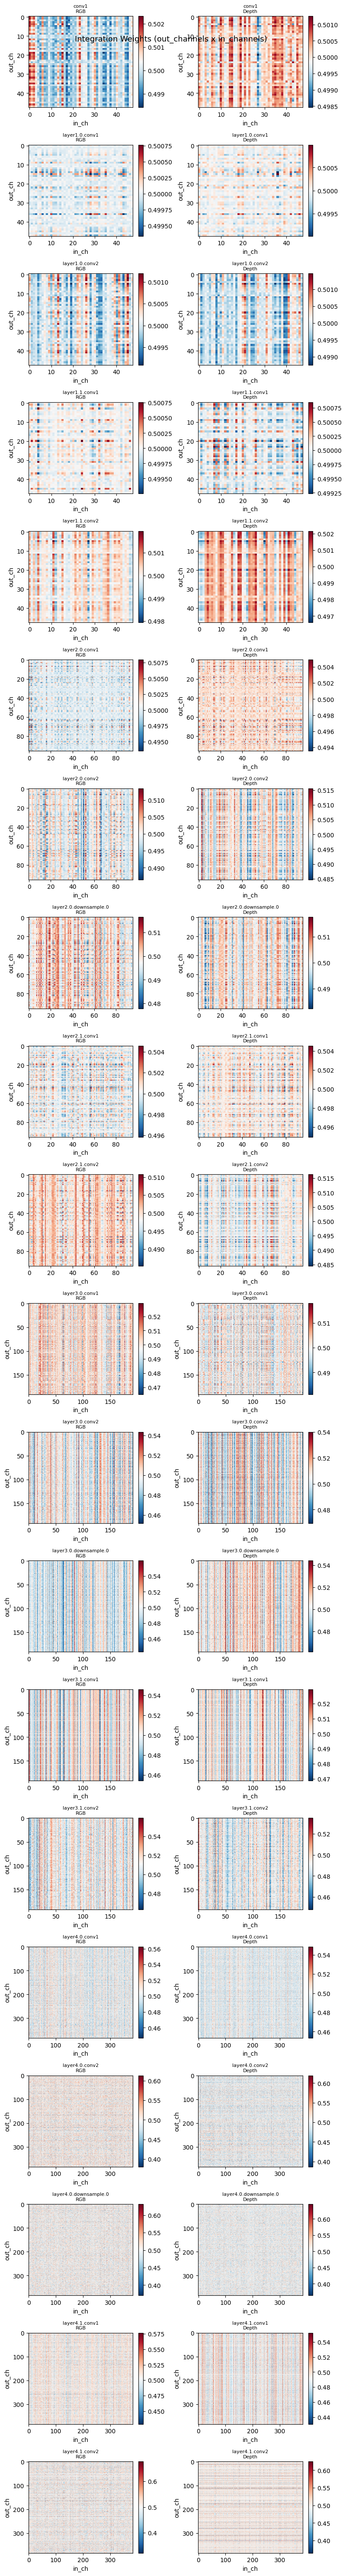


--- Cross-Stream Weight Comparison ---


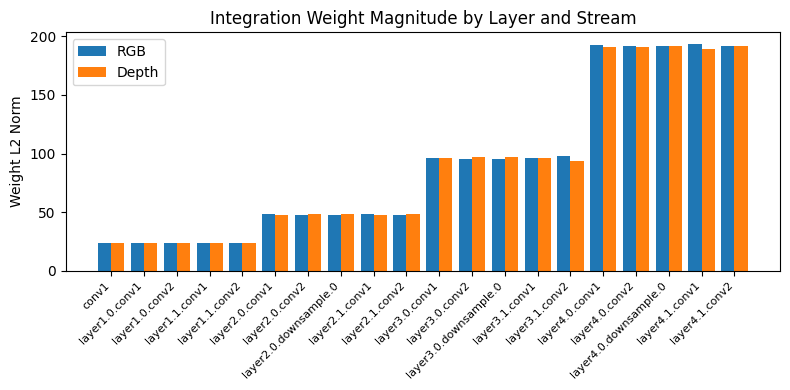


--- Effective Rank (SVD) ---
  conv1: ['1.0', '1.0']
  layer1.0.conv1: ['1.0', '1.0']
  layer1.0.conv2: ['1.0', '1.0']
  layer1.1.conv1: ['1.0', '1.0']
  layer1.1.conv2: ['1.0', '1.0']
  layer2.0.conv1: ['1.0', '1.0']
  layer2.0.conv2: ['1.1', '1.1']
  layer2.0.downsample.0: ['1.1', '1.1']
  layer2.1.conv1: ['1.0', '1.0']
  layer2.1.conv2: ['1.1', '1.1']
  layer3.0.conv1: ['1.3', '1.2']
  layer3.0.conv2: ['1.5', '1.3']
  layer3.0.downsample.0: ['1.4', '1.3']
  layer3.1.conv1: ['1.3', '1.2']
  layer3.1.conv2: ['1.5', '1.4']
  layer4.0.conv1: ['2.4', '1.9']
  layer4.0.conv2: ['4.5', '4.0']
  layer4.0.downsample.0: ['5.2', '4.7']
  layer4.1.conv1: ['2.1', '1.9']
  layer4.1.conv2: ['3.6', '2.2']

Integration weight visualization complete!


In [27]:
# --- 17d. Integration Weight Visualization ---
# Visualize the learned integration_from_streams weights per layer

iw_viz = IntegrationWeightVisualizer(model, stream_labels=STREAM_LABELS)

# Weight heatmaps per layer and stream
print('--- Integration Weights (Heatmaps) ---')
iw_viz.visualize_weights(save_path=f'{checkpoint_dir}/integration_weights.png')

# Cross-stream comparison (relative weight magnitudes per layer)
print('\n--- Cross-Stream Weight Comparison ---')
iw_viz.visualize_cross_stream(save_path=f'{checkpoint_dir}/integration_cross_stream.png')

# Effective rank via SVD (how low-dimensional is the integration?)
print('\n--- Effective Rank (SVD) ---')
ranks = iw_viz.compute_effective_rank()
for layer, r in ranks.items():
    print(f'  {layer}: {[f"{x:.1f}" for x in r]}')

print('\nIntegration weight visualization complete!')

In [ ]:
# --- 17e. Stream Redundancy Analysis ---
# Are RGB and Depth learning the same features? Or complementary ones?
# Uses centered cosine similarity between stream feature maps at each layer.

redundancy = StreamRedundancyAnalyzer(model, stream_labels=STREAM_LABELS)

print('--- Stream Redundancy (Centered Cosine Similarity) ---')
sim_results = redundancy.analyze(
    test_loader,
    n=128,  # Average over 128 samples
    save_path=f'{checkpoint_dir}/stream_redundancy.png'
)

# Print similarity matrices
for layer_name, sim_matrix in sim_results.items():
    print(f'\n{layer_name}:')
    for i in range(sim_matrix.shape[0]):
        row = '  '.join(f'{sim_matrix[i,j]:.3f}' for j in range(sim_matrix.shape[1]))
        print(f'  {STREAM_LABELS.get(i, f"S{i}")}: {row}')

print('\nStream redundancy analysis complete!')

--- Per-Class Stream Dominance (layer4) ---


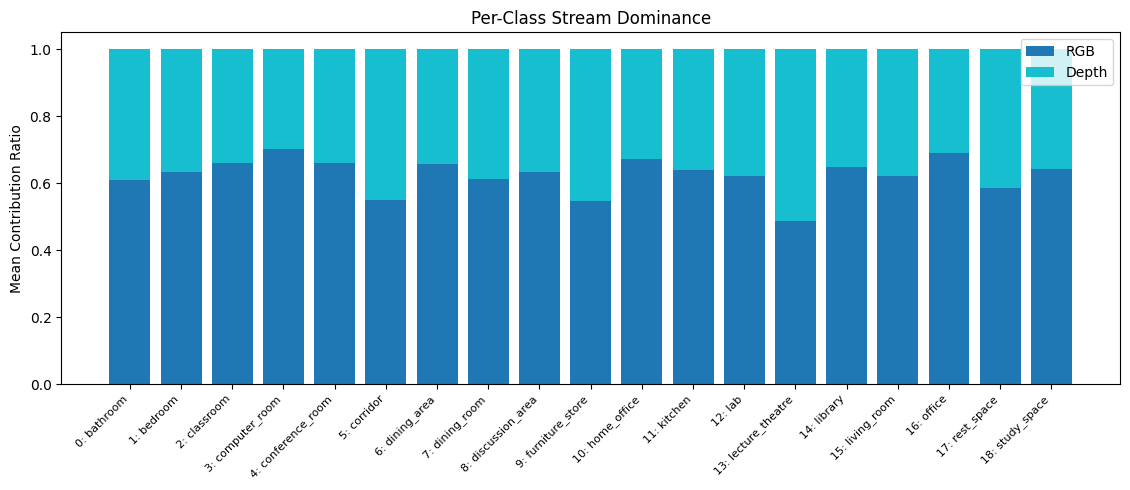


Per-class stream contribution ratios:
  0: bathroom: RGB: 60.83%, Depth: 39.17%
  1: bedroom: RGB: 63.21%, Depth: 36.79%
  2: classroom: RGB: 66.06%, Depth: 33.94%
  3: computer_room: RGB: 70.19%, Depth: 29.81%
  4: conference_room: RGB: 66.05%, Depth: 33.95%
  5: corridor: RGB: 54.95%, Depth: 45.05%
  6: dining_area: RGB: 65.74%, Depth: 34.26%
  7: dining_room: RGB: 61.37%, Depth: 38.63%
  8: discussion_area: RGB: 63.26%, Depth: 36.74%
  9: furniture_store: RGB: 54.70%, Depth: 45.30%
  10: home_office: RGB: 67.23%, Depth: 32.77%
  11: kitchen: RGB: 63.95%, Depth: 36.05%
  12: lab: RGB: 62.16%, Depth: 37.84%
  13: lecture_theatre: RGB: 48.82%, Depth: 51.18%
  14: library: RGB: 64.87%, Depth: 35.13%
  15: living_room: RGB: 62.12%, Depth: 37.88%
  16: office: RGB: 68.92%, Depth: 31.08%
  17: rest_space: RGB: 58.41%, Depth: 41.59%
  18: study_space: RGB: 64.18%, Depth: 35.82%

Per-class dominance analysis complete!


In [29]:
# --- 17f. Per-Class Stream Dominance ---
# Which scenes rely on RGB vs Depth?
# "Depth matters more for bathrooms, RGB dominates corridors"

# Build class name mapping
class_name_map = {i: name for i, name in enumerate(class_names)} if 'class_names' in dir() else None

dominance = PerClassDominanceAnalyzer(model, stream_labels=STREAM_LABELS)

print('--- Per-Class Stream Dominance (layer4) ---')
class_dominance = dominance.analyze(
    test_loader,
    layer='layer4',
    class_names=class_name_map,
    save_path=f'{checkpoint_dir}/per_class_dominance.png'
)

# Print per-class ratios
print('\nPer-class stream contribution ratios:')
for cls_idx, ratios in sorted(class_dominance.items()):
    name = class_name_map[cls_idx] if class_name_map else f'Class {cls_idx}'
    ratio_str = ', '.join(f'{STREAM_LABELS.get(i, f"S{i}")}: {r:.2%}' for i, r in enumerate(ratios))
    print(f'  {name}: {ratio_str}')

print('\nPer-class dominance analysis complete!')

--- Finding Misclassified Samples ---
Found 10 misclassified samples:
  [0] True: 6: dining_area, Predicted: 1: bedroom, Confidence: 23.69%
  [1] True: 12: lab, Predicted: 16: office, Confidence: 17.88%
  [2] True: 7: dining_room, Predicted: 5: corridor, Confidence: 62.86%
  [3] True: 8: discussion_area, Predicted: 2: classroom, Confidence: 45.56%
  [4] True: 2: classroom, Predicted: 3: computer_room, Confidence: 62.27%

--- Grad-CAM on Misclassified: True=6: dining_area, Pred=1: bedroom ---


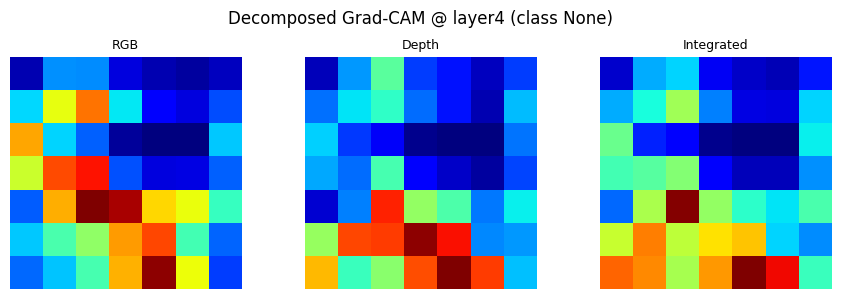


--- Finding correctly classified sample from class 6: dining_area ---
  Found correct sample (confidence: 89.10%)

--- Correct vs Misclassified Comparison ---


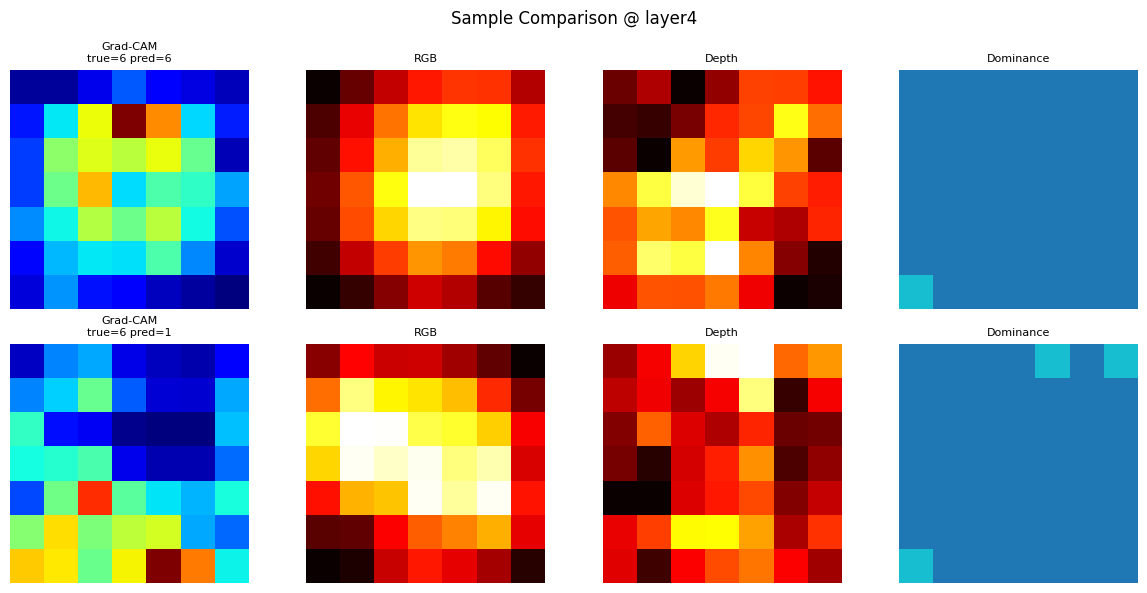


Misclassification analysis complete!


In [30]:
# --- 17g. Misclassification Analysis + Sample Comparison ---
# Find misclassified samples and compare with correctly classified ones

print('--- Finding Misclassified Samples ---')
misclassified = find_misclassified(model, test_loader, n=10)

print(f'Found {len(misclassified)} misclassified samples:')
for i, mc in enumerate(misclassified[:5]):
    true_name = class_names[mc['true_label']] if 'class_names' in dir() else str(mc['true_label'])
    pred_name = class_names[mc['predicted_label']] if 'class_names' in dir() else str(mc['predicted_label'])
    print(f'  [{i}] True: {true_name}, Predicted: {pred_name}, Confidence: {mc["confidence"]:.2%}')

# Grad-CAM on first misclassified sample
if misclassified:
    mc_sample = misclassified[0]
    mc_inputs = [s.to(model.device) for s in mc_sample['stream_inputs']]
    true_name = class_names[mc_sample['true_label']] if 'class_names' in dir() else str(mc_sample['true_label'])
    pred_name = class_names[mc_sample['predicted_label']] if 'class_names' in dir() else str(mc_sample['predicted_label'])
    print(f'\n--- Grad-CAM on Misclassified: True={true_name}, Pred={pred_name} ---')
    gradcam.visualize(mc_inputs, layer='layer4', mode='decomposed',
                      save_path=f'{checkpoint_dir}/gradcam_misclassified_0.png')

# Compare correct vs misclassified from same class
if misclassified:
    target_class = misclassified[0]['true_label']
    print(f'\n--- Finding correctly classified sample from class {class_names[target_class] if "class_names" in dir() else target_class} ---')

    # Find a correctly classified sample from the same class
    correct_sample = None
    model.eval()
    with torch.no_grad():
        for batch_data in test_loader:
            *stream_batches, targets = batch_data
            stream_batches_dev = [s.to(model.device) for s in stream_batches]
            targets_dev = targets.to(model.device)
            logits = model(stream_batches_dev)
            preds = logits.argmax(dim=1)
            # Find correctly classified samples of the target class
            mask = (targets_dev == target_class) & (preds == target_class)
            if mask.any():
                idx = mask.nonzero(as_tuple=True)[0][0].item()
                correct_sample = {
                    'stream_inputs': [s[idx:idx+1].cpu() for s in stream_batches],
                    'true_label': target_class,
                    'predicted_label': target_class,
                    'confidence': torch.softmax(logits[idx], dim=0)[target_class].item(),
                }
                break

    if correct_sample is not None:
        print(f'  Found correct sample (confidence: {correct_sample["confidence"]:.2%})')
        print('\n--- Correct vs Misclassified Comparison ---')
        compare_samples(
            model,
            correct_sample=correct_sample,
            misclassified_sample=misclassified[0],
            layer='layer4',
            stream_labels=STREAM_LABELS,
            save_path=f'{checkpoint_dir}/compare_samples.png'
        )
    else:
        print('  No correctly classified sample found for this class.')

print('\nMisclassification analysis complete!')

--- Train vs Test Activation Divergence ---


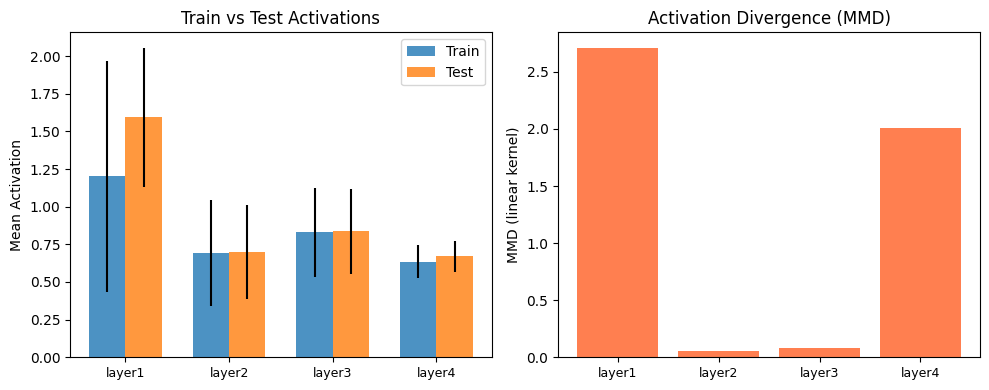

  layer1: MMD=2.7111
  layer2: MMD=0.0524
  layer3: MMD=0.0816
  layer4: MMD=2.0128

Activation divergence analysis complete!


In [31]:
# --- 17h. Train vs Test Activation Divergence ---
# Does the model see different activation distributions on train vs test?
# Uses MMD (Maximum Mean Discrepancy) per layer.

div_analyzer = ActivationDivergenceAnalyzer(model)

print('--- Train vs Test Activation Divergence ---')
divergence = div_analyzer.analyze(
    train_loader,
    test_loader,
    n=128,
    save_path=f'{checkpoint_dir}/activation_divergence.png'
)

for layer_name, metrics in divergence.items():
    print(f'  {layer_name}: MMD={metrics["mmd"]:.4f}')

print('\nActivation divergence analysis complete!')

In [32]:
# --- 17i. BN Stats Reset Experiment (Oracle Diagnostic) ---
# WARNING: This is a DIAGNOSTIC tool, not a deployable fix.
# It recomputes BN running stats on test data (oracle) to check if
# BN statistics drift causes the generalization gap.

import copy

# Save original accuracy
original_test_results = model.evaluate(test_loader)
original_acc = original_test_results['accuracy']
print(f'Original test accuracy: {original_acc*100:.2f}%')

# Control: recompute BN stats on TRAIN set (should be ~same)
print('\n--- Control: Recompute BN stats on TRAIN set ---')
model_control = copy.deepcopy(model)
reset_bn_stats(model_control, train_loader)
control_results = model_control.evaluate(test_loader)
control_acc = control_results['accuracy']
print(f'After train BN reset: {control_acc*100:.2f}% (delta: {(control_acc-original_acc)*100:+.2f}%)')

# Oracle: recompute BN stats on TEST set
print('\n--- Oracle: Recompute BN stats on TEST set ---')
model_oracle = copy.deepcopy(model)
reset_bn_stats(model_oracle, test_loader)
oracle_results = model_oracle.evaluate(test_loader)
oracle_acc = oracle_results['accuracy']
print(f'After test BN reset (oracle): {oracle_acc*100:.2f}% (delta: {(oracle_acc-original_acc)*100:+.2f}%)')

# Interpretation
print('\n--- Interpretation ---')
oracle_delta = (oracle_acc - original_acc) * 100
if abs(oracle_delta) > 2:
    print(f'BN stats drift accounts for ~{oracle_delta:+.1f}% of the gap.')
    print('Consider: test-time BN adaptation, larger batch size, or more training data.')
else:
    print(f'BN stats drift is minimal ({oracle_delta:+.1f}%). Gap is likely from other sources.')

del model_control, model_oracle  # Free memory
print('\nBN reset experiment complete!')

Original test accuracy: 49.56%

--- Control: Recompute BN stats on TRAIN set ---
After train BN reset: 49.84% (delta: +0.28%)

--- Oracle: Recompute BN stats on TEST set ---
After test BN reset (oracle): 48.19% (delta: -1.37%)

--- Interpretation ---
BN stats drift is minimal (-1.4%). Gap is likely from other sources.

BN reset experiment complete!


## 18. Summary

All training diagnostics and visualization analyses are saved to the checkpoint directory on Google Drive.

**Saved models:**
- `best_model.pt` - Best model checkpoint (by training loss, since no val set)
- `final_model.pt` - Final model with full state dict, optimizer, scheduler, history

**Saved data:**
- `training_history.json` - Full training history, configs, test results, pathway analysis
- `integration_snapshots/` - Periodic full integration weight snapshots (every N epochs)

**Saved visualizations:**
- `training_diagnostics.png` - 2x3 grid: loss, accuracy, LR, gradient norms, stream losses, gradient health
- `integration_weight_evolution.png` - Per-stream integration weight norms over training epochs
- `integration_weight_snapshots.png` - Detailed weight heatmaps at snapshot epochs
- `featuremaps_*.png` - What the CNN sees (full model, per-stream isolated, ablation, batch-averaged)
- `contributions_*.png` - Per-stream contribution magnitudes at each layer
- `gradcam_*.png` - Spatial attention maps (integrated, per-stream, decomposed, multi-layer)
- `gradcam_misclassified_0.png` - Decomposed Grad-CAM on a misclassified sample
- `integration_weights.png` - Learned fusion weight heatmaps per layer
- `integration_cross_stream.png` - Cross-stream weight magnitude comparison
- `stream_redundancy.png` - Centered cosine similarity between stream features per layer
- `per_class_dominance.png` - Which scenes rely on RGB vs Depth
- `activation_divergence.png` - Train vs test activation distribution shift (MMD) per layer
- `compare_samples.png` - Correct vs misclassified side-by-side (Grad-CAM + contributions)